# dcrypt-region marker informativeness

Train GIN models and quantify which fate markers are informative for curvature prediction inside dcrypt-defined regions. The analysis includes region-wise baseline performance, marker-removal ablations, local receptive-field marker counts, a crypt-only comparison between crypt domains with/without LGR5, and whole-organoid marker-removal contexts for LGR5 and Serotonin+Lysozyme+Chroma.


**Setup**

Import shared libraries and define paths relative to the project root.

In [70]:
import copy
import json
import pickle
import sys
from collections import deque
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

Configure the dataset, dcrypt region definitions, model size, training parameters, and analysis budgets. Marker ablation is intentionally run in `single` mode only: one marker-positive cell is removed per perturbation case.

In [ ]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Optional target residualization against a train-only global-feature baseline
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split settings
VAL_FRAC = 0.3
SPLIT_SEED = None

# dcrypt region settings
DCRYPT_FIELD = "d_crypts_graph"
DCRYPT_REGION_ORDER = [
    "dcrypt_lt_0p8",
    "dcrypt_0p8_to_1p2",
    "dcrypt_gt_1p2",
    "no_crypt",
]
DCRYPT_REGION_LABELS = {
    "dcrypt_lt_0p8": "dcrypt < 0.75",
    "dcrypt_0p8_to_1p2": "0.75 <= dcrypt <= 1.2",
    "dcrypt_gt_1p2": "dcrypt > 1.2",
    "no_crypt": "no crypt",
    "crypt_with_LGR5": "LGR5+ crypt",
    "crypt_without_LGR5": "LGR5- crypt",
    "crypt_with_LGR5_removed": "LGR5+ crypt\ntrained/eval LGR5 removed",
    "crypt_with_LGR5_eval_removed": "LGR5+ crypt\nfull model, LGR5 removed eval",
    "crypt_with_LGR5_crypt_markers_removed": "LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma removed",
    "crypt_with_LGR5_crypt_markers_eval_removed": "LGR5+ crypt\nfull model, Sero+Lyso+Chroma removed eval",
}
CRYPT_COMPARISON_ORDER = [
    "crypt_with_LGR5",
    "crypt_without_LGR5",
    "crypt_with_LGR5_removed",
    "crypt_with_LGR5_eval_removed",
]
CRYPT_MARKER_REMOVAL_COMPARISON_ORDER = [
    "crypt_with_LGR5",
    "crypt_with_LGR5_crypt_markers_removed",
    "crypt_with_LGR5_crypt_markers_eval_removed",
]
ANALYSIS_GROUP_ORDER = DCRYPT_REGION_ORDER + CRYPT_COMPARISON_ORDER + [
    group for group in CRYPT_MARKER_REMOVAL_COMPARISON_ORDER
    if group not in CRYPT_COMPARISON_ORDER
]
LGR5_MARKER_NAME = "LGR5"
CRYPT_REMOVAL_MARKER_NAMES = ["Serotonin", "Lysozyme", "Chroma"]
CRYPT_REMOVAL_MARKER_LABEL = "+".join(CRYPT_REMOVAL_MARKER_NAMES)

# Model settings
MODEL_CLASS = "GINCurvature"
NUM_LAYERS = 2
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Ablation and receptive-field analysis settings
ABLATION_MODES = ["single", "all"]
ABLATION_NORMALIZE_BY = "perturbed_cells"
ABLATION_NORMALIZE_BY_BY_MODE = {
    "single": ABLATION_NORMALIZE_BY,
    "all": "cases",
}
MAX_SUBGRAPHS_PER_GROUP = 2000
MIN_GROUP_NODES = 30
PERTURBATION_BATCH_SIZE = 128
LOCAL_COUNT_HOPS = NUM_LAYERS
RANDOM_SEED = 0

# Experiment output settings
EXPERIMENT_GROUP = "dcrypt_region_marker_informativeness"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"

In [72]:
def save_mpl_figure(fig, name, *, dpi=300):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figure -> {path}")
    return path


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def marker_index(name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if name in marker_names_in:
        return marker_names_in.index(name)
    lower = {str(m).lower(): i for i, m in enumerate(marker_names_in)}
    key = str(name).lower()
    if key not in lower:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names_in}")
    return lower[key]


def spearman_corr(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    xr = pd.Series(x[mask]).rank(method="average").to_numpy(dtype=float)
    yr = pd.Series(y[mask]).rank(method="average").to_numpy(dtype=float)
    if np.std(xr) == 0 or np.std(yr) == 0:
        return np.nan
    return float(np.corrcoef(xr, yr)[0, 1])


def display_table(df, *, columns=None, head=None):
    """Display a notebook-facing table while keeping machine keys in the stored dataframe."""
    out = df.copy()
    out = out.drop(columns=["group"], errors="ignore")
    if columns is not None:
        out = out[[col for col in columns if col in out.columns]]
    if head is not None:
        out = out.head(int(head))
    display(out)


def zero_marker_channel(graphs_in, marker_name, marker_names_in, *, inplace=False):
    """Return graphs where one marker channel has been set to zero."""
    marker_idx = marker_index(marker_name, marker_names_in)
    graphs_out = graphs_in if inplace else [copy.deepcopy(g) for g in graphs_in]
    for g in graphs_out:
        g.x = g.x.clone()
        g.x[:, marker_idx] = 0
    return graphs_out


def zero_marker_channels(graphs_in, marker_names_to_remove, marker_names_in, *, inplace=False):
    """Return graphs where one or more marker channels have been set to zero everywhere."""
    markers_to_remove = list(marker_names_to_remove)
    marker_indices = [marker_index(marker_name, marker_names_in) for marker_name in markers_to_remove]
    graphs_out = graphs_in if inplace else [copy.deepcopy(g) for g in graphs_in]
    n_positive_zeroed_by_marker = {marker_name: 0 for marker_name in markers_to_remove}
    n_nodes = 0
    for g in graphs_out:
        g.x = g.x.clone()
        n_nodes += int(g.x.shape[0])
        for marker_name, marker_idx in zip(markers_to_remove, marker_indices):
            marker_values = g.x[:, marker_idx].detach().cpu().numpy()
            n_positive_zeroed_by_marker[marker_name] += int(np.sum(marker_values > 0.5))
            g.x[:, marker_idx] = 0
    return graphs_out, {
        "markers": markers_to_remove,
        "region": "whole organoid",
        "n_nodes_zeroed": n_nodes,
        "n_positive_nodes_zeroed_by_marker": n_positive_zeroed_by_marker,
    }


**Data Loading**

Load graph data, attach organoid metadata, select the curvature target, and read marker names.

In [73]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)

Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


**Filtering**

Apply the same blacklist, organoid-quality filters, spherical-organoid rescue logic, and optional target outlier interpolation used in the other experiment notebooks.

In [74]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.metadata import fill_missing_metadata_for_group
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(
        graphs,
        blacklist,
        print_summary=True,
    )
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                243    341    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         288    409    0.704
20251201         day4p5              193    274    0.704
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------

**Global Features**

Create `global_feat` from log-transformed organoid-level metadata when global features are enabled.

In [75]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


**Split And Target Transform**

Split organoids into train and validation sets, standardize global features using the training set, and fit the target transform.

In [76]:
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

baseline_residual_transform = None
if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    if not USE_GLOBAL_FEATURES:
        raise ValueError("SUBTRACT_CONSTANT_GLOBAL_BASELINE requires USE_GLOBAL_FEATURES=True.")
    baseline_residual_transform = GlobalBaselineResidualTransform(num_workers=NUM_WORKERS)
    target_transform = ChainedTargetTransform([
        baseline_residual_transform,
        AsinhStandardizeTransform(robust=True),
    ])
    training_target_description = "target residual: true curvature - global-feature baseline"
else:
    target_transform = AsinhStandardizeTransform(robust=True)
    training_target_description = "raw target"

print("Training target:", training_target_description)

target_transform.fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)

Split -> train: 559 | val: 240
Training target: raw target
global_dim = 4
target_transform = asinh_standardize


**Training Setup**

Define the GIN model and training configuration, including the edge smoothness auxiliary loss.

In [77]:
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


**Model Training**

Train one all-marker GIN model. All downstream analyses ask how marker information supports this trained model in different dcrypt regions.

In [78]:
print(f"Training all-marker {MODEL_CLASS} | depth={NUM_LAYERS}")
model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(NUM_LAYERS),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
model, metrics, history = train(model, g_train, g_val, cfg)
training_log = {
    "model_class": MODEL_CLASS,
    "variant": "all_markers",
    "num_layers": int(NUM_LAYERS),
    "metrics": metrics,
    "history": history,
}

print(f"Training all-marker {MODEL_CLASS} with {LGR5_MARKER_NAME} channel zeroed | depth={NUM_LAYERS}")
g_train_lgr5_removed = zero_marker_channel(g_train, LGR5_MARKER_NAME, marker_names, inplace=False)
g_val_lgr5_removed = zero_marker_channel(g_val, LGR5_MARKER_NAME, marker_names, inplace=False)

model_lgr5_removed = GINCurvature(
    n_markers=int(g_train_lgr5_removed[0].x.size(1)),
    global_dim=infer_global_dim(g_train_lgr5_removed),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(NUM_LAYERS),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
model_lgr5_removed, metrics_lgr5_removed, history_lgr5_removed = train(
    model_lgr5_removed,
    g_train_lgr5_removed,
    g_val_lgr5_removed,
    cfg,
)
lgr5_removed_training_log = {
    "model_class": MODEL_CLASS,
    "variant": "LGR5_removed",
    "zeroed_marker": LGR5_MARKER_NAME,
    "num_layers": int(NUM_LAYERS),
    "metrics": metrics_lgr5_removed,
    "history": history_lgr5_removed,
}

print(f"Training {MODEL_CLASS} with {CRYPT_REMOVAL_MARKER_LABEL} channels zeroed in whole organoids | depth={NUM_LAYERS}")
g_train_crypt_markers_removed, train_crypt_markers_removed_info = zero_marker_channels(
    g_train,
    CRYPT_REMOVAL_MARKER_NAMES,
    marker_names,
    inplace=False,
)
g_val_crypt_markers_removed, val_crypt_markers_removed_info = zero_marker_channels(
    g_val,
    CRYPT_REMOVAL_MARKER_NAMES,
    marker_names,
    inplace=False,
)
print("Train whole-organoid crypt-marker zeroing:", train_crypt_markers_removed_info)
print("Val whole-organoid crypt-marker zeroing:", val_crypt_markers_removed_info)

model_crypt_markers_removed = GINCurvature(
    n_markers=int(g_train_crypt_markers_removed[0].x.size(1)),
    global_dim=infer_global_dim(g_train_crypt_markers_removed),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(NUM_LAYERS),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
model_crypt_markers_removed, metrics_crypt_markers_removed, history_crypt_markers_removed = train(
    model_crypt_markers_removed,
    g_train_crypt_markers_removed,
    g_val_crypt_markers_removed,
    cfg,
)
crypt_markers_removed_training_log = {
    "model_class": MODEL_CLASS,
    "variant": "crypt_markers_removed_whole_organoid",
    "zeroed_markers": list(CRYPT_REMOVAL_MARKER_NAMES),
    "zeroing_region": "whole organoid",
    "train_zeroing_info": train_crypt_markers_removed_info,
    "val_zeroing_info": val_crypt_markers_removed_info,
    "num_layers": int(NUM_LAYERS),
    "metrics": metrics_crypt_markers_removed,
    "history": history_crypt_markers_removed,
}
print("Finished training.")

Training all-marker GINCurvature | depth=2
epoch 001 | train loss 0.5516 mae 0.7847 | val loss 0.5213 mae 0.7725
epoch 002 | train loss 0.4873 mae 0.7469 | val loss 0.4872 mae 0.7439
epoch 003 | train loss 0.4638 mae 0.7273 | val loss 0.4621 mae 0.7296
epoch 004 | train loss 0.4439 mae 0.7173 | val loss 0.4453 mae 0.7181
epoch 005 | train loss 0.4333 mae 0.7073 | val loss 0.4290 mae 0.7101
epoch 006 | train loss 0.4243 mae 0.7025 | val loss 0.4222 mae 0.7061
epoch 007 | train loss 0.4164 mae 0.6970 | val loss 0.4107 mae 0.6947
epoch 008 | train loss 0.4102 mae 0.6936 | val loss 0.4036 mae 0.6922
epoch 009 | train loss 0.4065 mae 0.6879 | val loss 0.4054 mae 0.6980
epoch 010 | train loss 0.3998 mae 0.6869 | val loss 0.3963 mae 0.6829
epoch 011 | train loss 0.3984 mae 0.6870 | val loss 0.3915 mae 0.6829
epoch 012 | train loss 0.3946 mae 0.6811 | val loss 0.3869 mae 0.6843
epoch 013 | train loss 0.3887 mae 0.6809 | val loss 0.3866 mae 0.6820
epoch 014 | train loss 0.3858 mae 0.6788 | val 

**Validation Predictions**

Predict curvature and variance on all validation nodes. These arrays are the reference for baseline performance, marker-count correlations, and ablation MSE changes.

In [79]:
from src.inference.predict import predict_targets


def predict_model_arrays(graphs_in, model_in):
    y_true_i, y_pred_i, log_var_i, _ = predict_targets(
        graphs_in,
        model_in,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )
    y_true_i = select_target_column(y_true_i, TARGET_INDEX_FOR_PLOTS)
    y_pred_i = select_target_column(y_pred_i, TARGET_INDEX_FOR_PLOTS)
    log_var_i = select_target_column(log_var_i, TARGET_INDEX_FOR_PLOTS)
    pred_var_i = np.exp(log_var_i)
    sqerr_i = (y_pred_i - y_true_i) ** 2
    return {
        "y_true": y_true_i,
        "y_pred": y_pred_i,
        "log_var": log_var_i,
        "pred_var": pred_var_i,
        "sqerr": sqerr_i,
    }


pred_full = predict_model_arrays(g_val, model)
pred_lgr5_removed = predict_model_arrays(g_val_lgr5_removed, model_lgr5_removed)
pred_full_eval_lgr5_removed = predict_model_arrays(g_val_lgr5_removed, model)
pred_crypt_markers_removed = predict_model_arrays(g_val_crypt_markers_removed, model_crypt_markers_removed)
pred_full_eval_crypt_markers_removed = predict_model_arrays(g_val_crypt_markers_removed, model)

for context_label, pred_ctx in {
    "LGR5-removed trained/eval model": pred_lgr5_removed,
    "full model evaluated with LGR5 removed": pred_full_eval_lgr5_removed,
    "crypt-marker-removed trained/eval model": pred_crypt_markers_removed,
    "full model evaluated with crypt markers removed": pred_full_eval_crypt_markers_removed,
}.items():
    if not np.allclose(pred_full["y_true"], pred_ctx["y_true"], equal_nan=True):
        raise RuntimeError(f"Validation truth differs between full and {context_label} contexts.")

y_true = pred_full["y_true"]
y_pred = pred_full["y_pred"]
log_var = pred_full["log_var"]
pred_var = pred_full["pred_var"]
sqerr = pred_full["sqerr"]

y_pred_lgr5_removed = pred_lgr5_removed["y_pred"]
log_var_lgr5_removed = pred_lgr5_removed["log_var"]
pred_var_lgr5_removed = pred_lgr5_removed["pred_var"]
sqerr_lgr5_removed = pred_lgr5_removed["sqerr"]

y_pred_full_eval_lgr5_removed = pred_full_eval_lgr5_removed["y_pred"]
log_var_full_eval_lgr5_removed = pred_full_eval_lgr5_removed["log_var"]
pred_var_full_eval_lgr5_removed = pred_full_eval_lgr5_removed["pred_var"]
sqerr_full_eval_lgr5_removed = pred_full_eval_lgr5_removed["sqerr"]

y_pred_crypt_markers_removed = pred_crypt_markers_removed["y_pred"]
log_var_crypt_markers_removed = pred_crypt_markers_removed["log_var"]
pred_var_crypt_markers_removed = pred_crypt_markers_removed["pred_var"]
sqerr_crypt_markers_removed = pred_crypt_markers_removed["sqerr"]

y_pred_full_eval_crypt_markers_removed = pred_full_eval_crypt_markers_removed["y_pred"]
log_var_full_eval_crypt_markers_removed = pred_full_eval_crypt_markers_removed["log_var"]
pred_var_full_eval_crypt_markers_removed = pred_full_eval_crypt_markers_removed["pred_var"]
sqerr_full_eval_crypt_markers_removed = pred_full_eval_crypt_markers_removed["sqerr"]

prediction_contexts = {
    "full": pred_full,
    "lgr5_removed": pred_lgr5_removed,
    "full_eval_lgr5_removed": pred_full_eval_lgr5_removed,
    "crypt_markers_removed": pred_crypt_markers_removed,
    "full_eval_crypt_markers_removed": pred_full_eval_crypt_markers_removed,
}
model_contexts = {
    "full": {
        "model": model,
        "graphs": g_val,
        "label_suffix": "full model",
    },
    "lgr5_removed": {
        "model": model_lgr5_removed,
        "graphs": g_val_lgr5_removed,
        "label_suffix": f"{LGR5_MARKER_NAME} removed train/eval model",
    },
    "full_eval_lgr5_removed": {
        "model": model,
        "graphs": g_val_lgr5_removed,
        "label_suffix": f"full model evaluated with {LGR5_MARKER_NAME} removed",
    },
    "crypt_markers_removed": {
        "model": model_crypt_markers_removed,
        "graphs": g_val_crypt_markers_removed,
        "label_suffix": f"{CRYPT_REMOVAL_MARKER_LABEL} removed train/eval model",
    },
    "full_eval_crypt_markers_removed": {
        "model": model,
        "graphs": g_val_crypt_markers_removed,
        "label_suffix": f"full model evaluated with {CRYPT_REMOVAL_MARKER_LABEL} removed",
    },
}
MODEL_CONTEXT_BY_GROUP = {
    "crypt_with_LGR5_removed": "lgr5_removed",
    "crypt_with_LGR5_eval_removed": "full_eval_lgr5_removed",
    "crypt_with_LGR5_crypt_markers_removed": "crypt_markers_removed",
    "crypt_with_LGR5_crypt_markers_eval_removed": "full_eval_crypt_markers_removed",
}

print("Validation nodes:", len(y_true))
print("MSE:", float(np.mean(sqerr)))
print("Mean predicted variance:", float(np.mean(pred_var)))
print("Spearman(predicted variance, squared residual):", spearman_corr(pred_var, sqerr))
print(f"MSE ({LGR5_MARKER_NAME} removed train/eval model):", float(np.mean(sqerr_lgr5_removed)))
print(f"Mean predicted variance ({LGR5_MARKER_NAME} removed train/eval model):", float(np.mean(pred_var_lgr5_removed)))
print(
    f"Spearman(predicted variance, squared residual; {LGR5_MARKER_NAME} removed train/eval model):",
    spearman_corr(pred_var_lgr5_removed, sqerr_lgr5_removed),
)
print(f"MSE (full model evaluated with {LGR5_MARKER_NAME} removed):", float(np.mean(sqerr_full_eval_lgr5_removed)))
print(f"Mean predicted variance (full model evaluated with {LGR5_MARKER_NAME} removed):", float(np.mean(pred_var_full_eval_lgr5_removed)))
print(
    f"Spearman(predicted variance, squared residual; full model evaluated with {LGR5_MARKER_NAME} removed):",
    spearman_corr(pred_var_full_eval_lgr5_removed, sqerr_full_eval_lgr5_removed),
)

print(f"MSE ({CRYPT_REMOVAL_MARKER_LABEL} removed train/eval model):", float(np.mean(sqerr_crypt_markers_removed)))
print(f"Mean predicted variance ({CRYPT_REMOVAL_MARKER_LABEL} removed train/eval model):", float(np.mean(pred_var_crypt_markers_removed)))
print(
    f"Spearman(predicted variance, squared residual; {CRYPT_REMOVAL_MARKER_LABEL} removed train/eval model):",
    spearman_corr(pred_var_crypt_markers_removed, sqerr_crypt_markers_removed),
)
print(f"MSE (full model evaluated with {CRYPT_REMOVAL_MARKER_LABEL} removed):", float(np.mean(sqerr_full_eval_crypt_markers_removed)))
print(f"Mean predicted variance (full model evaluated with {CRYPT_REMOVAL_MARKER_LABEL} removed):", float(np.mean(pred_var_full_eval_crypt_markers_removed)))
print(
    f"Spearman(predicted variance, squared residual; full model evaluated with {CRYPT_REMOVAL_MARKER_LABEL} removed):",
    spearman_corr(pred_var_full_eval_crypt_markers_removed, sqerr_full_eval_crypt_markers_removed),
)


Validation nodes: 110362
MSE: 0.0032219933952689936
Mean predicted variance: 0.001887512815947315
Spearman(predicted variance, squared residual): 0.332475612925399
MSE (LGR5 removed train/eval model): 0.003320505400357644
Mean predicted variance (LGR5 removed train/eval model): 0.0019165838666441895
Spearman(predicted variance, squared residual; LGR5 removed train/eval model): 0.32129602256186435
MSE (full model evaluated with LGR5 removed): 0.003360441191948838
Mean predicted variance (full model evaluated with LGR5 removed): 0.0018908791177332394
Spearman(predicted variance, squared residual; full model evaluated with LGR5 removed): 0.3310896905258671
MSE (Serotonin+Lysozyme+Chroma removed train/eval model): 0.003346792140487744
Mean predicted variance (Serotonin+Lysozyme+Chroma removed train/eval model): 0.0018749903534799014
Spearman(predicted variance, squared residual; Serotonin+Lysozyme+Chroma removed train/eval model): 0.33321882877300174
MSE (full model evaluated with Serotoni

**dcrypt Regions**

Convert the per-organoid `d_crypts_graph` metadata into one dcrypt value per validation node, then build the four broad region masks.

In [80]:
from src.data.metadata import get_graph_metadata


def _nanmin_or_nan(values, axis):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    filled = np.where(finite, arr, np.inf)
    out = np.min(filled, axis=axis)
    has_finite = np.any(finite, axis=axis)
    out = np.asarray(out, dtype=float)
    out[~has_finite] = np.nan
    return out


def _min_node_dcrypt_from_raw(raw, n_nodes):
    arr = np.asarray(raw, dtype=float)

    if arr.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    if arr.ndim == 0:
        return np.full(n_nodes, float(arr), dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] == n_nodes:
            return arr.astype(float)
        if arr.shape[0] == 1:
            return np.full(n_nodes, float(arr[0]), dtype=float)
        raise ValueError(f"Cannot align 1-D dcrypt with length {arr.shape[0]} to {n_nodes} nodes.")

    if n_nodes in arr.shape:
        node_axis = list(arr.shape).index(n_nodes)
        moved = np.moveaxis(arr, node_axis, 0).reshape(n_nodes, -1)
        return _nanmin_or_nan(moved, axis=1)

    if arr.ndim >= 2 and arr.shape[1] >= n_nodes:
        vals = _nanmin_or_nan(arr, axis=0)
    else:
        vals = _nanmin_or_nan(arr, axis=1)

    vals = np.asarray(vals, dtype=float).reshape(-1)
    if vals.shape[0] != n_nodes:
        raise ValueError(f"Transformed dcrypt has length {vals.shape[0]}, expected {n_nodes}.")
    return vals


def compute_min_dcrypt_by_graphs(graphs_in, *, meta_lookup=None, field=DCRYPT_FIELD):
    values_by_graph = []
    for g in graphs_in:
        n_nodes = int(g.y.shape[0])
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=False, default={})
        raw = md.get(field, np.asarray([], dtype=float))
        values_by_graph.append(_min_node_dcrypt_from_raw(raw, n_nodes))
    return values_by_graph, np.concatenate(values_by_graph, axis=0)


def dcrypt_region_masks(dcrypt_values):
    dcrypt_values = np.asarray(dcrypt_values, dtype=float).reshape(-1)
    finite = np.isfinite(dcrypt_values)
    return {
        "dcrypt_lt_0p8": finite & (dcrypt_values < 0.75),
        "dcrypt_0p8_to_1p2": finite & (dcrypt_values >= 0.75) & (dcrypt_values <= 1.2),
        "dcrypt_gt_1p2": finite & (dcrypt_values > 1.2),
        "no_crypt": ~finite,
    }


min_dcrypt_by_graph, min_dcrypt_by_node = compute_min_dcrypt_by_graphs(
    g_val,
    meta_lookup=val_meta_lookup,
    field=DCRYPT_FIELD,
)
if len(min_dcrypt_by_node) != len(y_true):
    raise ValueError(
        f"dcrypt length {len(min_dcrypt_by_node)} does not match validation target length {len(y_true)}."
    )

dcrypt_masks = dcrypt_region_masks(min_dcrypt_by_node)
dcrypt_region_count_df = pd.DataFrame([
    {
        "group": key,
        "label": DCRYPT_REGION_LABELS[key],
        "n_nodes": int(dcrypt_masks[key].sum()),
    }
    for key in DCRYPT_REGION_ORDER
])
display_table(dcrypt_region_count_df)

,label,n_nodes
0,dcrypt < 0.65,19889
1,0.65 <= dcrypt <= 1.2,26254
2,dcrypt > 1.2,46919
3,no crypt,17300


**Crypt Domains And Marker-Removal Contexts**

Within `dcrypt < 0.8`, connected crypt domains are split by whether the domain contains at least one LGR5-positive cell. Additional categories reuse those crypt-domain masks while routing evaluation through marker-removed model contexts: LGR5 removed everywhere, or Serotonin+Lysozyme+Chroma removed from the whole organoid.


In [81]:
def _build_undirected_adjacency(edge_index, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    ei = edge_index.detach().cpu().numpy() if hasattr(edge_index, "detach") else np.asarray(edge_index)
    for u, v in zip(ei[0], ei[1]):
        u = int(u)
        v = int(v)
        if u == v:
            continue
        adjacency[u].append(v)
        adjacency[v].append(u)
    return [sorted(set(neigh)) for neigh in adjacency]


def _connected_components_from_mask(adjacency, mask):
    mask = np.asarray(mask, dtype=bool)
    seen = np.zeros(len(mask), dtype=bool)
    components = []
    for start in np.where(mask)[0]:
        start = int(start)
        if seen[start]:
            continue
        queue = deque([start])
        seen[start] = True
        comp = []
        while queue:
            node = queue.popleft()
            comp.append(node)
            for nbr in adjacency[node]:
                if mask[nbr] and not seen[nbr]:
                    seen[nbr] = True
                    queue.append(nbr)
        components.append(sorted(comp))
    return components


def crypt_lgr5_domain_masks(graphs_in, dcrypt_by_graph, marker_names_in, marker_name=LGR5_MARKER_NAME):
    lgr5_idx = marker_index(marker_name, marker_names_in)
    has_lgr5_parts = []
    no_lgr5_parts = []

    for g, dvals in zip(graphs_in, dcrypt_by_graph):
        n_nodes = int(g.x.shape[0])
        crypt_mask = np.isfinite(dvals) & (np.asarray(dvals, dtype=float) < 0.8)
        has_lgr5 = np.zeros(n_nodes, dtype=bool)
        no_lgr5 = np.zeros(n_nodes, dtype=bool)
        if np.any(crypt_mask):
            x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
            marker_pos = x[:, lgr5_idx] > 0.5
            adjacency = _build_undirected_adjacency(g.edge_index, n_nodes)
            for comp in _connected_components_from_mask(adjacency, crypt_mask):
                comp = np.asarray(comp, dtype=int)
                if np.any(marker_pos[comp]):
                    has_lgr5[comp] = True
                else:
                    no_lgr5[comp] = True
        has_lgr5_parts.append(has_lgr5)
        no_lgr5_parts.append(no_lgr5)

    return {
        "crypt_with_LGR5": np.concatenate(has_lgr5_parts),
        "crypt_without_LGR5": np.concatenate(no_lgr5_parts),
    }


crypt_lgr5_masks = crypt_lgr5_domain_masks(g_val, min_dcrypt_by_graph, marker_names)
crypt_lgr5_masks["crypt_with_LGR5_removed"] = crypt_lgr5_masks["crypt_with_LGR5"].copy()
crypt_lgr5_masks["crypt_with_LGR5_eval_removed"] = crypt_lgr5_masks["crypt_with_LGR5"].copy()
crypt_lgr5_masks["crypt_with_LGR5_crypt_markers_removed"] = crypt_lgr5_masks["crypt_with_LGR5"].copy()
crypt_lgr5_masks["crypt_with_LGR5_crypt_markers_eval_removed"] = crypt_lgr5_masks["crypt_with_LGR5"].copy()
analysis_masks = {**dcrypt_masks, **crypt_lgr5_masks}

analysis_group_count_df = pd.DataFrame([
    {
        "group": key,
        "label": DCRYPT_REGION_LABELS[key],
        "n_nodes": int(analysis_masks[key].sum()),
    }
    for key in ANALYSIS_GROUP_ORDER
])
display_table(analysis_group_count_df)

,label,n_nodes
0,dcrypt < 0.65,19889
1,0.65 <= dcrypt <= 1.2,26254
2,dcrypt > 1.2,46919
3,no crypt,17300
4,LGR5+ crypt,16104
5,LGR5- crypt,6378
6,LGR5+ crypt\ntrained/eval LGR5 removed,16104
7,"LGR5+ crypt\nfull model, LGR5 removed eval",16104
8,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,16104
9,"LGR5+ crypt\nfull model, Sero+Lyso+Chroma remo...",16104


**Baseline Region Performance**

This table reports validation performance within each region: MSE, mean predicted variance, and the Spearman correlation between predicted variance and squared residuals. Larger positive Spearman values mean the model uncertainty better tracks its actual errors.

In [82]:
def arrays_for_group(group):
    context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
    return prediction_contexts[context_name]


def summarize_baseline_performance_by_group(group_masks):
    rows = []
    for group in ANALYSIS_GROUP_ORDER:
        mask = np.asarray(group_masks[group], dtype=bool)
        pred_ctx = arrays_for_group(group)
        n = int(mask.sum())
        if n == 0:
            mse = mean_var = rho = np.nan
            sem_mse = sem_var = np.nan
        else:
            mse_values = pred_ctx["sqerr"][mask]
            var_values = pred_ctx["pred_var"][mask]
            mse = float(np.mean(mse_values))
            mean_var = float(np.mean(var_values))
            sem_mse = float(np.std(mse_values, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
            sem_var = float(np.std(var_values, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
            rho = spearman_corr(var_values, mse_values)
        rows.append({
            "group": group,
            "label": DCRYPT_REGION_LABELS[group],
            "model_context": MODEL_CONTEXT_BY_GROUP.get(group, "full"),
            "n_nodes": n,
            "mse": mse,
            "sem_mse": sem_mse,
            "pred_var_mean": mean_var,
            "sem_pred_var": sem_var,
            "spearman_pred_var_sqerr": rho,
        })
    return pd.DataFrame(rows)


baseline_region_df = summarize_baseline_performance_by_group(analysis_masks)
display_table(baseline_region_df)

,label,model_context,n_nodes,mse,sem_mse,pred_var_mean,sem_pred_var,spearman_pred_var_sqerr
0,dcrypt < 0.65,full,19889,0.004008,0.000050,0.002557,0.000019,0.268688
1,0.65 <= dcrypt <= 1.2,full,26254,0.006601,0.000087,0.002635,0.000019,0.336572
2,dcrypt > 1.2,full,46919,0.001763,0.000027,0.001485,0.000007,0.259068
3,no crypt,full,17300,0.001146,0.000025,0.001075,0.000009,0.141534
4,LGR5+ crypt,full,16104,0.003982,0.000054,0.002919,0.000022,0.221160
5,LGR5- crypt,full,6378,0.003446,0.000091,0.001586,0.000025,0.358518
6,LGR5+ crypt\ntrained/eval LGR5 removed,lgr5_removed,16104,0.004395,0.000059,0.002847,0.000019,0.229936
7,"LGR5+ crypt\nfull model, LGR5 removed eval",full_eval_lgr5_removed,16104,0.004688,0.000063,0.003007,0.000023,0.229871
8,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,crypt_markers_removed,16104,0.004285,0.000059,0.003005,0.000022,0.217609
9,"LGR5+ crypt\nfull model, Sero+Lyso+Chroma remo...",full_eval_crypt_markers_removed,16104,0.005201,0.000067,0.002401,0.000016,0.249925


**Baseline Performance Plots**

The same region-wise baseline metrics are shown as bar plots for quick comparison across dcrypt categories, LGR5-defined crypt domains, and whole-organoid crypt-marker removal contexts.


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/baseline_performance_by_dcrypt_region.pdf


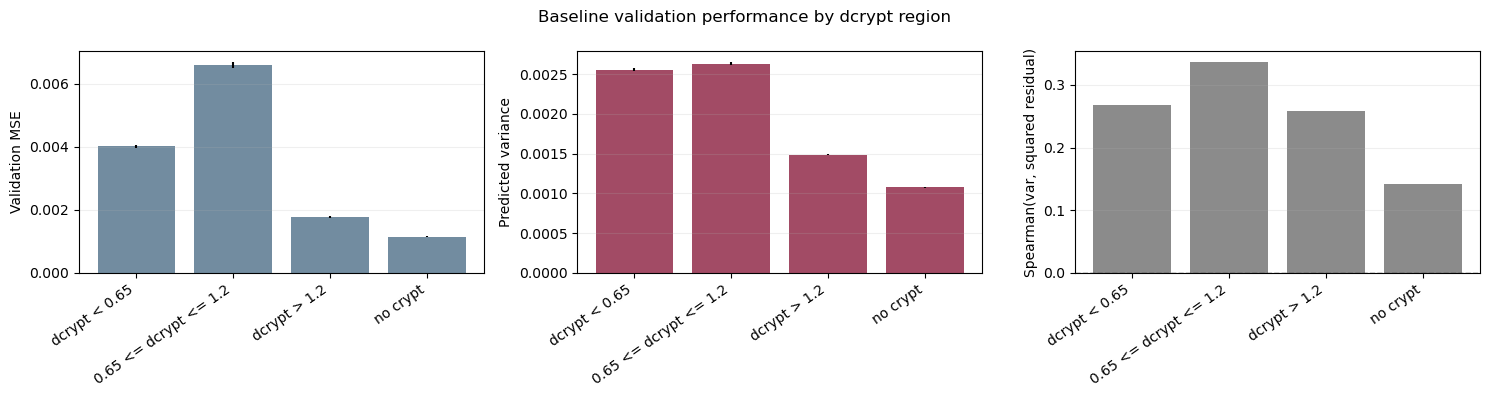

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/baseline_performance_by_crypt_lgr5_domain.pdf


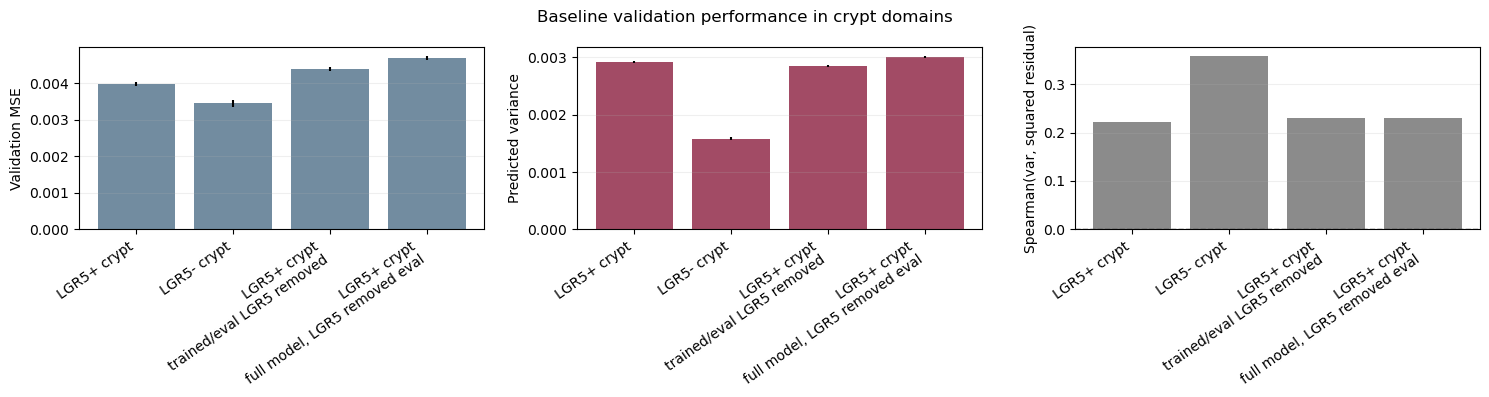

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/baseline_performance_by_crypt_marker_removal.pdf


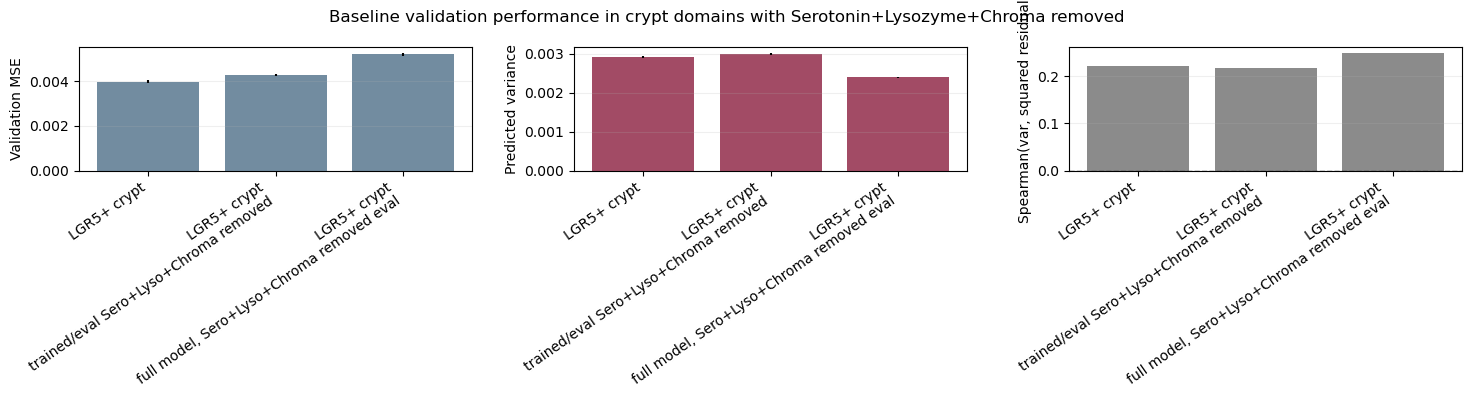

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: ylabel='Validation MSE'>,
        <Axes: ylabel='Predicted variance'>,
        <Axes: ylabel='Spearman(var, squared residual)'>], dtype=object))

In [83]:
def plot_baseline_performance(plot_df, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    x = np.arange(len(plot_df))
    labels = plot_df["label"].tolist()

    axes[0].bar(x, plot_df["mse"], yerr=plot_df["sem_mse"], color="#4f6f88", alpha=0.8)
    axes[0].set_ylabel("Validation MSE")

    axes[1].bar(x, plot_df["pred_var_mean"], yerr=plot_df["sem_pred_var"], color="#8b1e3f", alpha=0.8)
    axes[1].set_ylabel("Predicted variance")

    axes[2].bar(x, plot_df["spearman_pred_var_sqerr"], color="#6e6e6e", alpha=0.8)
    axes[2].axhline(0, color="0.25", linestyle="--", linewidth=1)
    axes[2].set_ylabel("Spearman(var, squared residual)")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.grid(True, axis="y", alpha=0.2)

    fig.suptitle(title)
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


plot_baseline_performance(
    baseline_region_df[baseline_region_df["group"].isin(DCRYPT_REGION_ORDER)],
    "Baseline validation performance by dcrypt region",
    "baseline_performance_by_dcrypt_region",
)
plot_baseline_performance(
    baseline_region_df[baseline_region_df["group"].isin(CRYPT_COMPARISON_ORDER)],
    "Baseline validation performance in crypt domains",
    "baseline_performance_by_crypt_lgr5_domain",
)
plot_baseline_performance(
    baseline_region_df[baseline_region_df["group"].isin(CRYPT_MARKER_REMOVAL_COMPARISON_ORDER)],
    f"Baseline validation performance in crypt domains with {CRYPT_REMOVAL_MARKER_LABEL} removed",
    "baseline_performance_by_crypt_marker_removal",
)


**Local Marker Counts**

For every validation node, count how many positive cells of each marker lie inside the model receptive field. These counts summarize the marker context available to the trained GIN.

In [84]:
from src.graph.neighborhood import compute_hop_rings


def count_markers_in_receptive_field_for_graph(graph, marker_names_in, num_hops):
    n_nodes = int(graph.x.shape[0])
    n_markers = len(marker_names_in)
    x = graph.x.detach().cpu().numpy() if hasattr(graph.x, "detach") else np.asarray(graph.x)
    xb = x[:, :n_markers] > 0.5
    counts = np.zeros((n_nodes, n_markers), dtype=np.int32)
    for center in range(n_nodes):
        rings = compute_hop_rings(graph.edge_index, center, int(num_hops))
        nodes = np.asarray([node for ring in rings for node in ring], dtype=int)
        if len(nodes):
            counts[center] = xb[nodes].sum(axis=0)
    return counts


rf_counts_by_graph = []
rf_counts_lgr5_removed_by_graph = []
rf_counts_crypt_markers_removed_by_graph = []
for gi, (g, g_lgr5_removed, g_crypt_markers_removed) in enumerate(zip(g_val, g_val_lgr5_removed, g_val_crypt_markers_removed)):
    rf_counts_by_graph.append(count_markers_in_receptive_field_for_graph(g, marker_names, LOCAL_COUNT_HOPS))
    rf_counts_lgr5_removed_by_graph.append(count_markers_in_receptive_field_for_graph(g_lgr5_removed, marker_names, LOCAL_COUNT_HOPS))
    rf_counts_crypt_markers_removed_by_graph.append(count_markers_in_receptive_field_for_graph(g_crypt_markers_removed, marker_names, LOCAL_COUNT_HOPS))
    if (gi + 1) % 25 == 0:
        print(f"Computed RF marker counts for {gi + 1}/{len(g_val)} graphs")

rf_marker_counts = np.concatenate(rf_counts_by_graph, axis=0)
rf_marker_counts_lgr5_removed = np.concatenate(rf_counts_lgr5_removed_by_graph, axis=0)
rf_marker_counts_crypt_markers_removed = np.concatenate(rf_counts_crypt_markers_removed_by_graph, axis=0)
rf_count_contexts = {
    "full": rf_marker_counts,
    "lgr5_removed": rf_marker_counts_lgr5_removed,
    "full_eval_lgr5_removed": rf_marker_counts_lgr5_removed,
    "crypt_markers_removed": rf_marker_counts_crypt_markers_removed,
    "full_eval_crypt_markers_removed": rf_marker_counts_crypt_markers_removed,
}


def center_marker_positive_matrix(graphs_in, marker_names_in):
    n_markers = len(marker_names_in)
    parts = []
    for g in graphs_in:
        x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
        parts.append(x[:, :n_markers] > 0.5)
    return np.concatenate(parts, axis=0)


center_marker_positive = center_marker_positive_matrix(g_val, marker_names)
center_marker_positive_lgr5_removed = center_marker_positive_matrix(g_val_lgr5_removed, marker_names)
center_marker_positive_crypt_markers_removed = center_marker_positive_matrix(g_val_crypt_markers_removed, marker_names)
center_marker_positive_contexts = {
    "full": center_marker_positive,
    "lgr5_removed": center_marker_positive_lgr5_removed,
    "full_eval_lgr5_removed": center_marker_positive_lgr5_removed,
    "crypt_markers_removed": center_marker_positive_crypt_markers_removed,
    "full_eval_crypt_markers_removed": center_marker_positive_crypt_markers_removed,
}
print("rf_marker_counts shape:", rf_marker_counts.shape)
print("rf_marker_counts_lgr5_removed shape:", rf_marker_counts_lgr5_removed.shape)

Computed RF marker counts for 25/240 graphs
Computed RF marker counts for 50/240 graphs
Computed RF marker counts for 75/240 graphs
Computed RF marker counts for 100/240 graphs
Computed RF marker counts for 125/240 graphs
Computed RF marker counts for 150/240 graphs
Computed RF marker counts for 175/240 graphs
Computed RF marker counts for 200/240 graphs
Computed RF marker counts for 225/240 graphs
rf_marker_counts shape: (110362, 7)
rf_marker_counts_lgr5_removed shape: (110362, 7)


**Marker Count Summary Table**

This table shows, for each region and marker, the average receptive-field count, how often the marker is visible, and Spearman correlations with true curvature, predicted curvature, squared residuals, and predicted variance.

In [85]:
def summarize_marker_counts_by_group(group_masks):
    rows = []
    for group in ANALYSIS_GROUP_ORDER:
        mask = np.asarray(group_masks[group], dtype=bool)
        pred_ctx = arrays_for_group(group)
        context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
        rf_counts = rf_count_contexts[context_name]
        center_marker_positive = center_marker_positive_contexts[context_name]
        n = int(mask.sum())
        for mi, marker in enumerate(marker_names):
            counts = rf_counts[:, mi]
            if n == 0:
                n_marker_positive = 0
                mean_count = frac_visible = rho_true = rho_pred = rho_sqerr = rho_var = np.nan
            else:
                c = counts[mask]
                n_marker_positive = int(center_marker_positive[mask, mi].sum())
                mean_count = float(np.mean(c))
                frac_visible = float(np.mean(c > 0))
                rho_true = spearman_corr(c, pred_ctx["y_true"][mask])
                rho_pred = spearman_corr(c, pred_ctx["y_pred"][mask])
                rho_sqerr = spearman_corr(c, pred_ctx["sqerr"][mask])
                rho_var = spearman_corr(c, pred_ctx["pred_var"][mask])
            rows.append({
                "group": group,
                "label": DCRYPT_REGION_LABELS[group],
                "model_context": MODEL_CONTEXT_BY_GROUP.get(group, "full"),
                "marker": marker,
                "marker_index": mi,
                "n_nodes": n,
                "n_marker_positive": n_marker_positive,
                "mean_count_within_rf": mean_count,
                "fraction_with_marker_visible": frac_visible,
                "spearman_count_true": rho_true,
                "spearman_count_pred": rho_pred,
                "spearman_count_sqerr": rho_sqerr,
                "spearman_count_pred_var": rho_var,
            })
    return pd.DataFrame(rows)


marker_count_region_df = summarize_marker_counts_by_group(analysis_masks)
display_table(marker_count_region_df, head=12)

,label,model_context,marker,marker_index,n_nodes,n_marker_positive,mean_count_within_rf,fraction_with_marker_visible,spearman_count_true,spearman_count_pred,spearman_count_sqerr,spearman_count_pred_var
0,dcrypt < 0.65,full,Agr2,0,19889,1667,1.514003,0.607421,0.205167,0.344016,0.069509,0.345341
1,dcrypt < 0.65,full,AldoB,1,19889,4474,4.654985,0.397104,-0.160783,-0.316863,-0.062669,-0.406222
2,dcrypt < 0.65,full,Chroma,2,19889,322,0.275931,0.143295,0.145079,0.301426,0.026514,0.189564
3,dcrypt < 0.65,full,KI67,3,19889,9406,9.103726,0.800593,0.034782,0.178926,-0.004959,0.235200
4,dcrypt < 0.65,full,LGR5,4,19889,7081,6.530846,0.586354,0.195030,0.485936,0.010816,0.279308
5,dcrypt < 0.65,full,Lysozyme,5,19889,1316,1.124340,0.389411,0.295055,0.548585,0.068483,0.411409
6,dcrypt < 0.65,full,Serotonin,6,19889,229,0.191915,0.132184,0.164596,0.340775,0.053647,0.213084
7,0.65 <= dcrypt <= 1.2,full,Agr2,0,26254,1189,0.958902,0.442256,0.074651,0.148485,0.008339,0.152095
8,0.65 <= dcrypt <= 1.2,full,AldoB,1,26254,9219,7.070351,0.633123,-0.046145,-0.145175,-0.012590,-0.120700
9,0.65 <= dcrypt <= 1.2,full,Chroma,2,26254,97,0.099718,0.059534,0.045961,0.156275,0.025944,0.066224


**Marker Count Heatmaps**

Heatmaps summarize local marker composition and marker-count correlations. The four dcrypt regions are plotted separately from the LGR5 crypt-domain comparison and from the whole-organoid crypt-marker removal comparison.


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/mean_rf_marker_count_by_dcrypt_regions.pdf


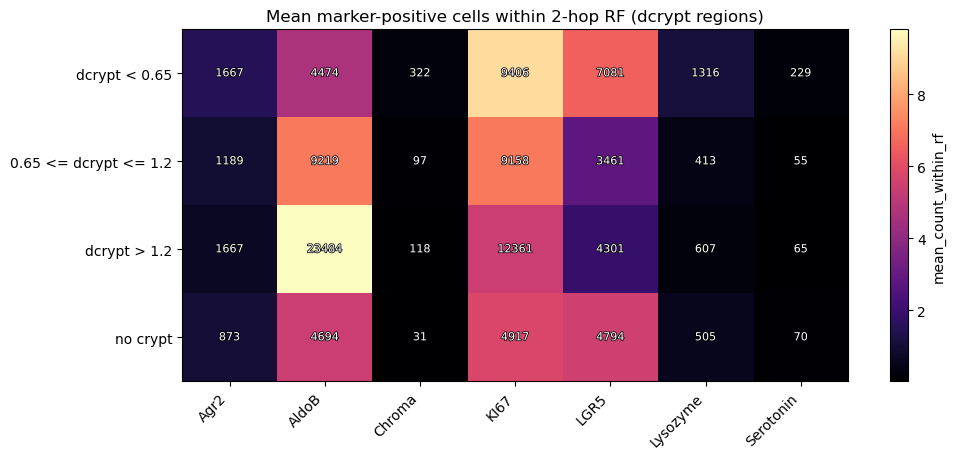

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_sqerr_by_dcrypt_regions.pdf


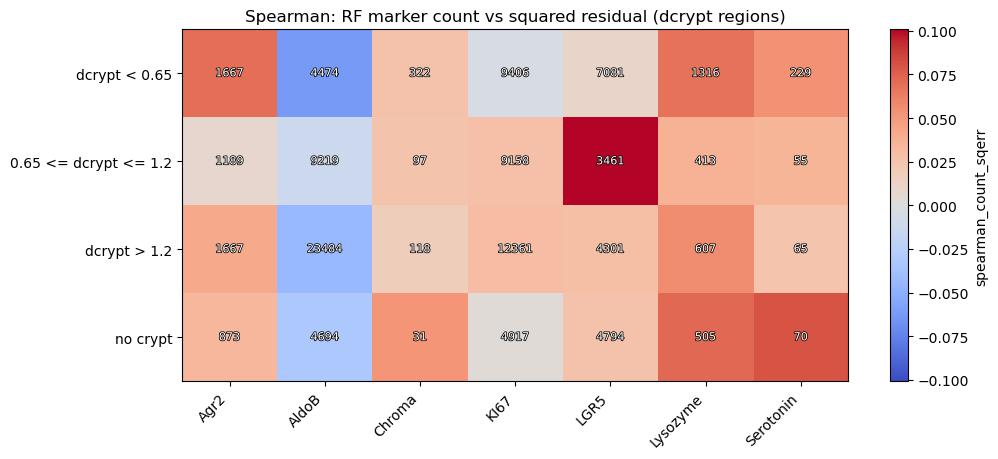

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_prediction_by_dcrypt_regions.pdf


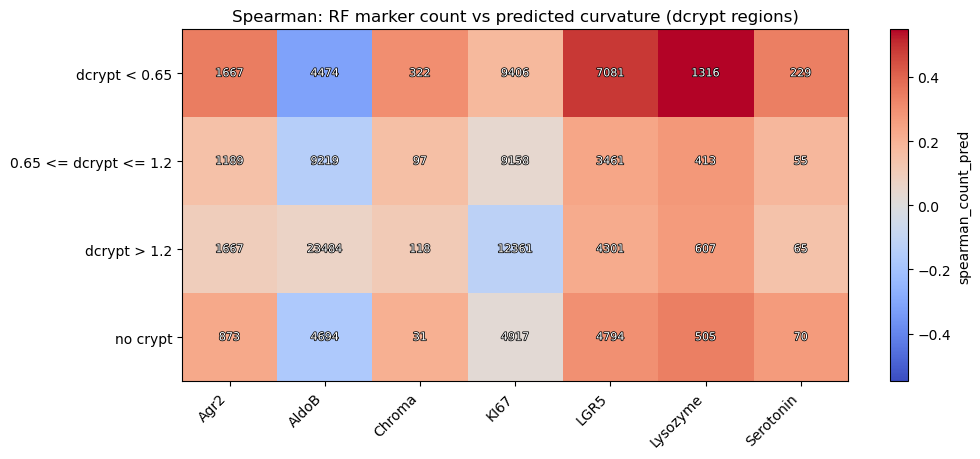

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_predicted_variance_by_dcrypt_regions.pdf


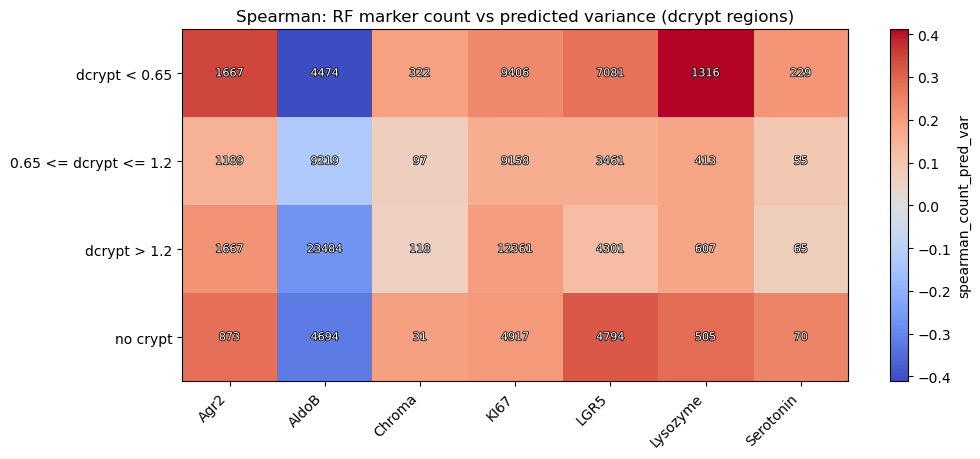

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_true_curvature_by_dcrypt_regions.pdf


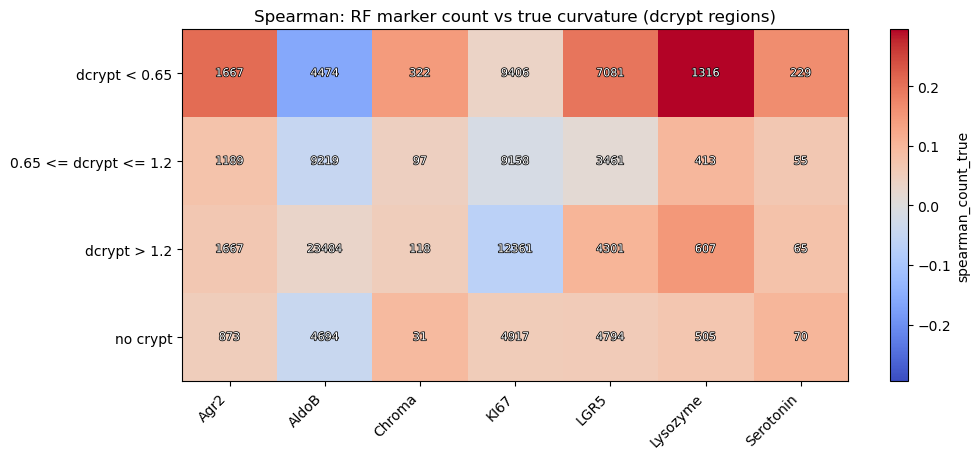

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/mean_rf_marker_count_by_crypt_lgr5_domains.pdf


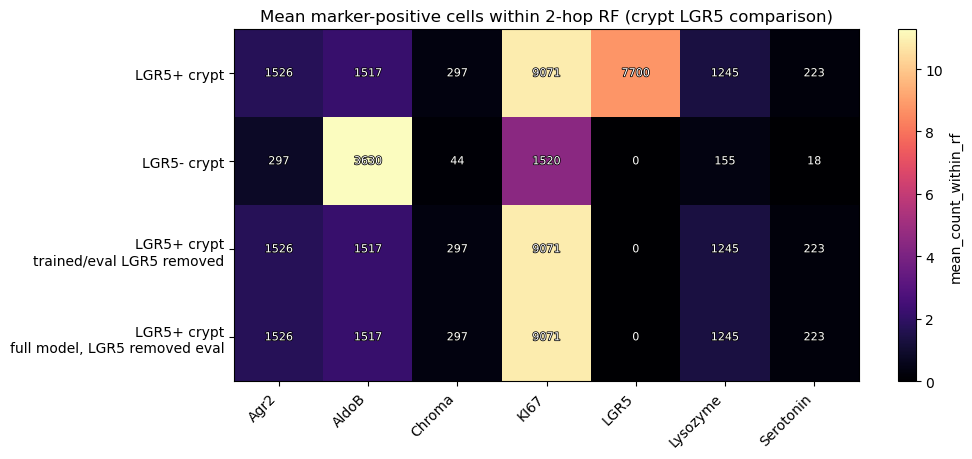

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_sqerr_by_crypt_lgr5_domains.pdf


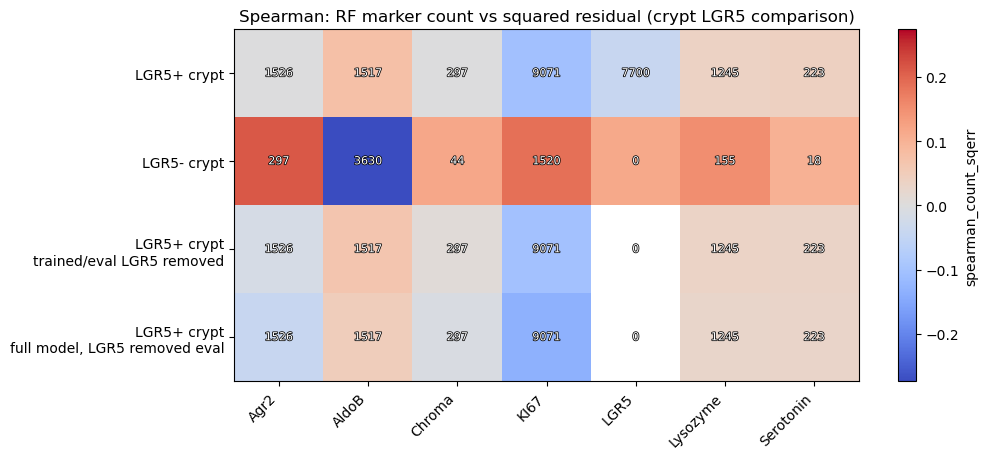

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_prediction_by_crypt_lgr5_domains.pdf


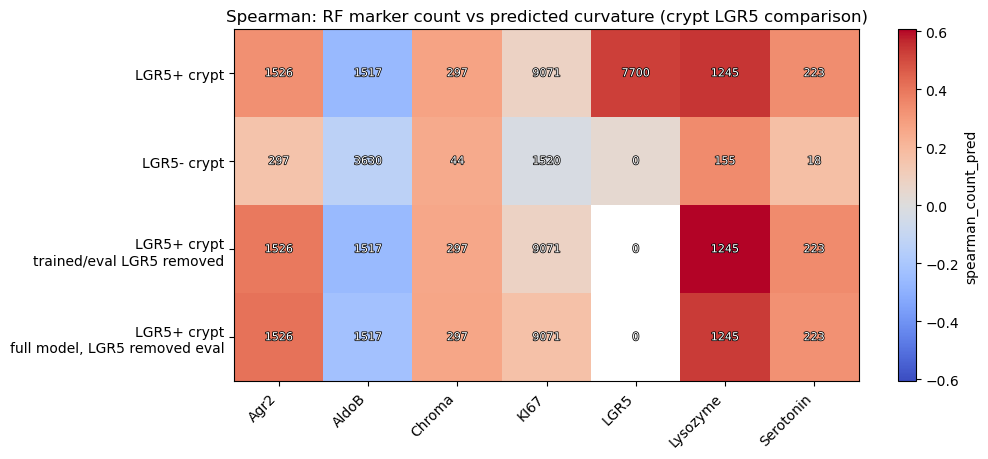

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_predicted_variance_by_crypt_lgr5_domains.pdf


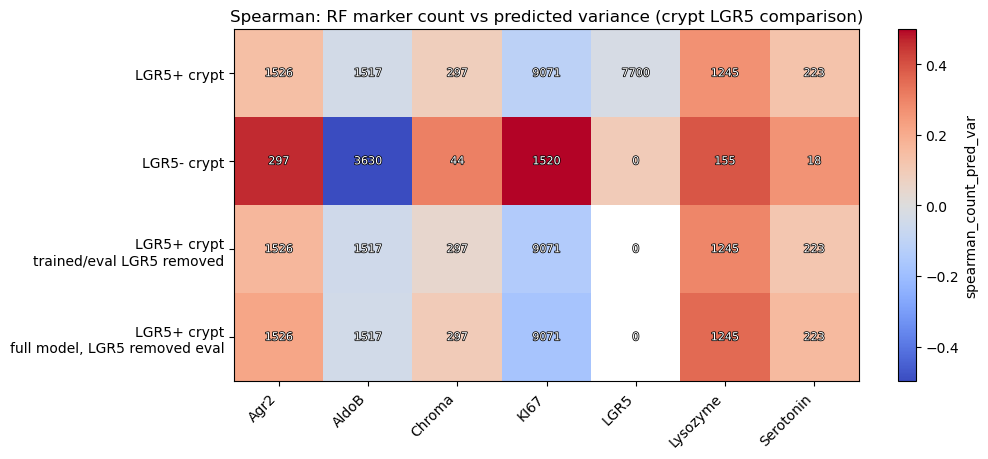

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_true_curvature_by_crypt_lgr5_domains.pdf


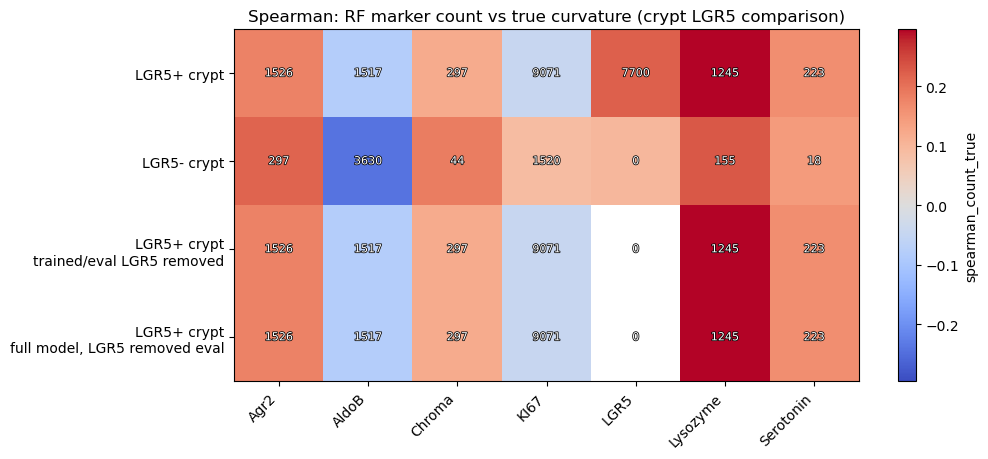

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/mean_rf_marker_count_by_crypt_marker_removal.pdf


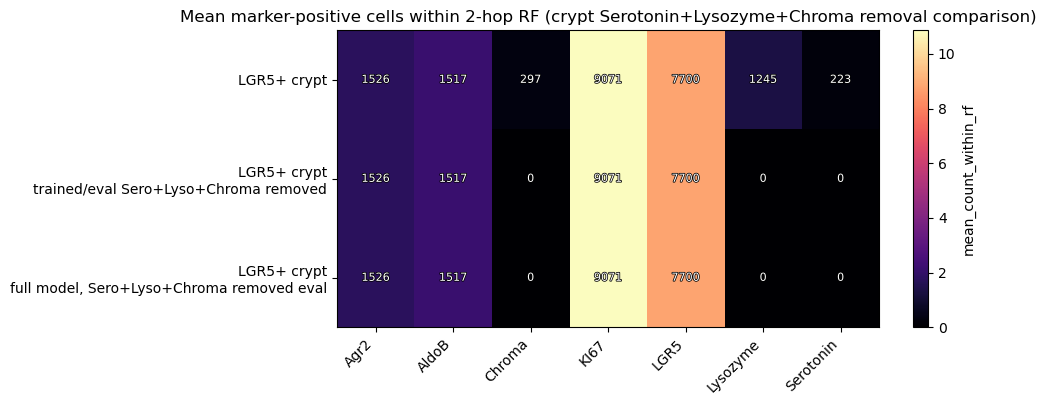

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_sqerr_by_crypt_marker_removal.pdf


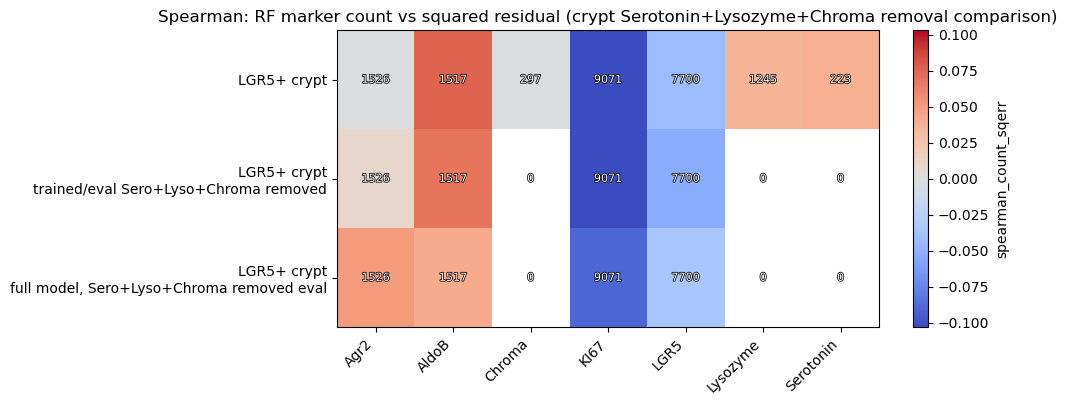

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_prediction_by_crypt_marker_removal.pdf


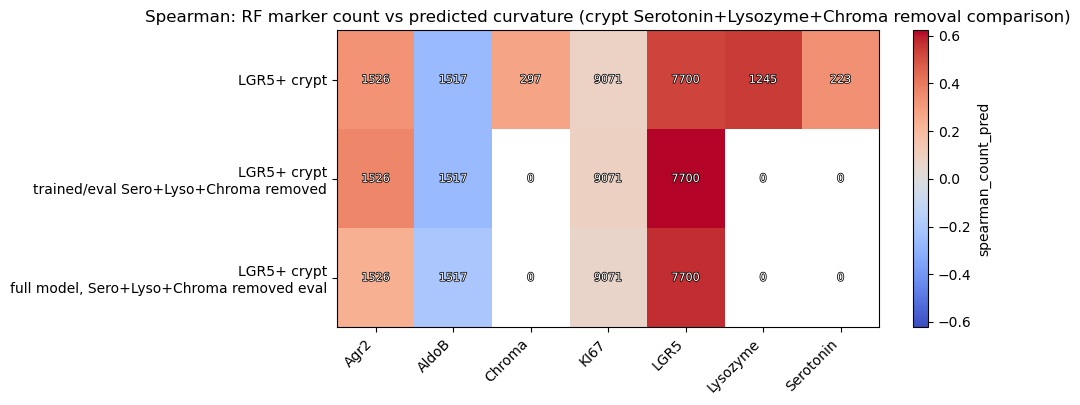

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_predicted_variance_by_crypt_marker_removal.pdf


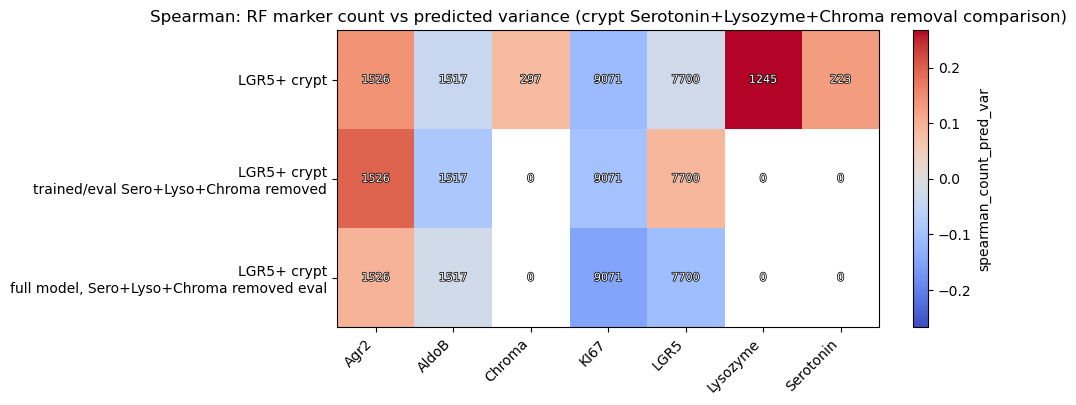

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/spearman_rf_marker_count_vs_true_curvature_by_crypt_marker_removal.pdf


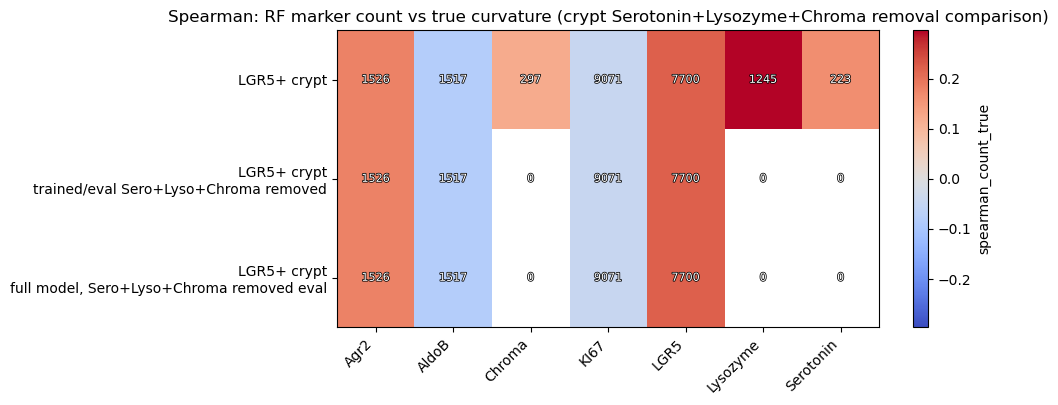

In [86]:
def annotate_heatmap_cells(ax, annotation_table, *, fontsize=8):
    values = annotation_table.to_numpy()
    for yi in range(values.shape[0]):
        for xi in range(values.shape[1]):
            value = values[yi, xi]
            if pd.isna(value):
                continue
            text = ax.text(
                xi,
                yi,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=fontsize,
                color="white",
            )
            text.set_path_effects([path_effects.withStroke(linewidth=1.1, foreground="black")])


def plot_group_marker_heatmap(
    df,
    value_col,
    title,
    filename,
    *,
    group_order,
    cmap="viridis",
    center_zero=False,
    annotation_col="n_marker_positive",
):
    sub = df[df["group"].isin(group_order)].copy()
    table = sub.pivot(index="label", columns="marker", values=value_col)
    row_labels = [DCRYPT_REGION_LABELS[g] for g in group_order if g in set(sub["group"])]
    table = table.reindex(row_labels)
    table = table[[m for m in marker_names if m in table.columns]]

    annotation_table = None
    if annotation_col is not None and annotation_col in sub.columns:
        annotation_table = sub.pivot(index="label", columns="marker", values=annotation_col)
        annotation_table = annotation_table.reindex(row_labels)
        annotation_table = annotation_table.reindex(columns=table.columns)

    fig, ax = plt.subplots(figsize=(1.05 * len(table.columns) + 3, 0.55 * len(table.index) + 2.5))
    values = table.to_numpy(dtype=float)
    if center_zero:
        vmax = np.nanmax(np.abs(values)) if np.any(np.isfinite(values)) else 1.0
        vmin = -vmax
    else:
        vmin = None
        vmax = None
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_title(title)
    if annotation_table is not None:
        annotate_heatmap_cells(ax, annotation_table)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_col)
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


for group_order, suffix, title_prefix in [
    (DCRYPT_REGION_ORDER, "dcrypt_regions", "dcrypt regions"),
    (CRYPT_COMPARISON_ORDER, "crypt_lgr5_domains", "crypt LGR5 comparison"),
    (CRYPT_MARKER_REMOVAL_COMPARISON_ORDER, "crypt_marker_removal", f"crypt {CRYPT_REMOVAL_MARKER_LABEL} removal comparison"),
]:
    plot_group_marker_heatmap(
        marker_count_region_df,
        "mean_count_within_rf",
        f"Mean marker-positive cells within {LOCAL_COUNT_HOPS}-hop RF ({title_prefix})",
        f"mean_rf_marker_count_by_{suffix}",
        group_order=group_order,
        cmap="magma",
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_sqerr",
        f"Spearman: RF marker count vs squared residual ({title_prefix})",
        f"spearman_rf_marker_count_vs_sqerr_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_pred",
        f"Spearman: RF marker count vs predicted curvature ({title_prefix})",
        f"spearman_rf_marker_count_vs_prediction_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_pred_var",
        f"Spearman: RF marker count vs predicted variance ({title_prefix})",
        f"spearman_rf_marker_count_vs_predicted_variance_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_true",
        f"Spearman: RF marker count vs true curvature ({title_prefix})",
        f"spearman_rf_marker_count_vs_true_curvature_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )


**Ablation Subgraphs**

Build sampled ego-subgraphs centered on nodes from each analysis group. These subgraphs are used for marker-removal perturbations.

In [87]:
from src.analysis.perturbation import (
    compute_perturbation_influence_maps,
    compute_perturbation_mse_influence_maps,
)
from src.data.subgraphs import build_ego_subgraphs_for_center_specs


def center_specs_from_flat_mask(graphs_in, flat_mask, *, max_centers=None, seed=0):
    flat_mask = np.asarray(flat_mask, dtype=bool).reshape(-1)
    specs = []
    offset = 0
    for gi, g in enumerate(graphs_in):
        n = int(g.x.shape[0])
        local = np.where(flat_mask[offset:offset + n])[0]
        specs.extend((gi, int(c)) for c in local)
        offset += n
    if max_centers is not None and len(specs) > int(max_centers):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(specs), size=int(max_centers), replace=False)
        specs = [specs[int(i)] for i in idx]
    return specs


def build_group_subgraphs(group_masks):
    out = {}
    info = []
    for group in ANALYSIS_GROUP_ORDER:
        context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
        graphs_for_group = model_contexts[context_name]["graphs"]
        specs = center_specs_from_flat_mask(
            graphs_for_group,
            group_masks[group],
            max_centers=MAX_SUBGRAPHS_PER_GROUP,
            seed=RANDOM_SEED,
        )
        if len(specs) == 0:
            out[group] = []
        else:
            out[group] = build_ego_subgraphs_for_center_specs(
                graphs_for_group,
                specs,
                num_hops=NUM_LAYERS,
                copy_graph_level_attrs=True,
            )
        info.append({
            "group": group,
            "label": DCRYPT_REGION_LABELS[group],
            "model_context": context_name,
            "n_nodes": int(np.asarray(group_masks[group], dtype=bool).sum()),
            "n_subgraphs": len(out[group]),
        })
    return out, pd.DataFrame(info)


group_subgraphs, group_subgraph_info = build_group_subgraphs(analysis_masks)
display_table(group_subgraph_info)

,label,model_context,n_nodes,n_subgraphs
0,dcrypt < 0.65,full,19889,2000
1,0.65 <= dcrypt <= 1.2,full,26254,2000
2,dcrypt > 1.2,full,46919,2000
3,no crypt,full,17300,2000
4,LGR5+ crypt,full,16104,2000
5,LGR5- crypt,full,6378,2000
6,LGR5+ crypt\ntrained/eval LGR5 removed,lgr5_removed,16104,2000
7,"LGR5+ crypt\nfull model, LGR5 removed eval",full_eval_lgr5_removed,16104,2000
8,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,crypt_markers_removed,16104,2000
9,"LGR5+ crypt\nfull model, Sero+Lyso+Chroma remo...",full_eval_crypt_markers_removed,16104,2000


**Marker Ablation**

For each sampled center cell, marker-positive neighbors are removed either one at a time (`single` mode) or all together (`all` mode). The table records how removal changes predicted curvature and squared error by hop distance and marker.


In [88]:
def perturbation_results_to_tables(result, mse_result, *, group, mode, normalize_by):
    rows = []
    hops = list(result["hops"])
    for hi, hop in enumerate(hops):
        for mi, marker in enumerate(marker_names):
            rows.append({
                "group": group,
                "label": DCRYPT_REGION_LABELS[group],
                "mode": mode,
                "normalize_by": normalize_by,
                "model_context": MODEL_CONTEXT_BY_GROUP.get(group, "full"),
                "hop": int(hop),
                "marker": marker,
                "marker_index": mi,
                "delta_mu": float(result["delta_mu_total"][hi, mi]),
                "abs_delta_mu": float(result["delta_mu_abs_total"][hi, mi]),
                "delta_mse": float(mse_result["delta_mse_total"][hi, mi]),
                "abs_delta_mse": float(mse_result["delta_mse_abs_total"][hi, mi]),
                "cases": int(result["cases_total"][hi, mi]),
                "perturbed_cells": int(result["counts_total"][hi, mi]),
            })
    return pd.DataFrame(rows)


ablation_results = {}
ablation_tables = []

for group in ANALYSIS_GROUP_ORDER:
    subs = group_subgraphs[group]
    if len(subs) < MIN_GROUP_NODES:
        print(f"Skipping {group}: only {len(subs)} subgraphs")
        continue
    for mode in ABLATION_MODES:
        normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, ABLATION_NORMALIZE_BY)
        print(f"Ablation | group={group} | mode={mode} | normalize_by={normalize_by} | subgraphs={len(subs)}")
        context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
        model_for_group = model_contexts[context_name]["model"]
        res = compute_perturbation_influence_maps(
            subgraphs=subs,
            model=model_for_group,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            max_subgraphs=None,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
            target_transform=target_transform,
            normalize_by=normalize_by,
        )
        mse_res = compute_perturbation_mse_influence_maps(
            subgraphs=subs,
            model=model_for_group,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            max_subgraphs=None,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
            target_transform=target_transform,
            normalize_by=normalize_by,
        )
        ablation_results[(group, mode)] = {
            "prediction": res,
            "mse": mse_res,
            "model_context": context_name,
            "normalize_by": normalize_by,
        }
        ablation_tables.append(
            perturbation_results_to_tables(res, mse_res, group=group, mode=mode, normalize_by=normalize_by)
        )

ablation_df = pd.concat(ablation_tables, ignore_index=True) if ablation_tables else pd.DataFrame()
display_table(ablation_df, head=12)

Ablation | group=dcrypt_lt_0p8 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=dcrypt_lt_0p8 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=dcrypt_0p8_to_1p2 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=dcrypt_0p8_to_1p2 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=dcrypt_gt_1p2 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=dcrypt_gt_1p2 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=no_crypt | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=no_crypt | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=crypt_with_LGR5 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=crypt_with_LGR5 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=crypt_without_LGR5 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=crypt_without_LGR5

,label,mode,normalize_by,model_context,hop,marker,marker_index,delta_mu,abs_delta_mu,delta_mse,abs_delta_mse,cases,perturbed_cells
0,dcrypt < 0.65,single,perturbed_cells,full,1,Agr2,0,-0.003628,0.006150,0.000311,0.000668,668,668
1,dcrypt < 0.65,single,perturbed_cells,full,1,AldoB,1,0.000455,0.005207,-0.000154,0.000512,622,622
2,dcrypt < 0.65,single,perturbed_cells,full,1,Chroma,2,-0.005561,0.009671,0.000505,0.001061,132,132
3,dcrypt < 0.65,single,perturbed_cells,full,1,KI67,3,-0.000412,0.003735,0.000088,0.000367,1409,1409
4,dcrypt < 0.65,single,perturbed_cells,full,1,LGR5,4,-0.002273,0.003980,0.000176,0.000429,956,956
5,dcrypt < 0.65,single,perturbed_cells,full,1,Lysozyme,5,-0.005626,0.007155,0.000398,0.000739,404,404
6,dcrypt < 0.65,single,perturbed_cells,full,1,Serotonin,6,-0.012531,0.015065,0.001417,0.001955,114,114
7,dcrypt < 0.65,single,perturbed_cells,full,2,Agr2,0,-0.000555,0.002477,0.000043,0.000265,1000,1000
8,dcrypt < 0.65,single,perturbed_cells,full,2,AldoB,1,0.000023,0.002947,0.000011,0.000298,804,804
9,dcrypt < 0.65,single,perturbed_cells,full,2,Chroma,2,-0.003307,0.004505,0.000254,0.000463,231,231


**Ablation Heatmaps**

Ablation heatmaps show signed prediction changes and MSE changes after marker removal. Positive `delta_mse` means the marker was helpful for accuracy; negative `delta_mse` means removing it improved the prediction.

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_by_dcrypt_regions_hop_marker_single.pdf


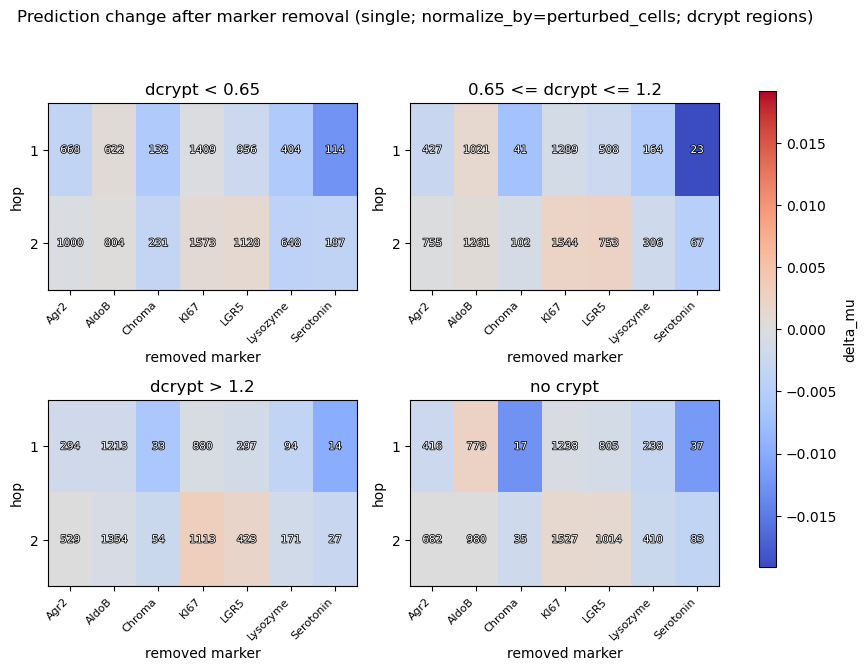

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_by_dcrypt_regions_hop_marker_single.pdf


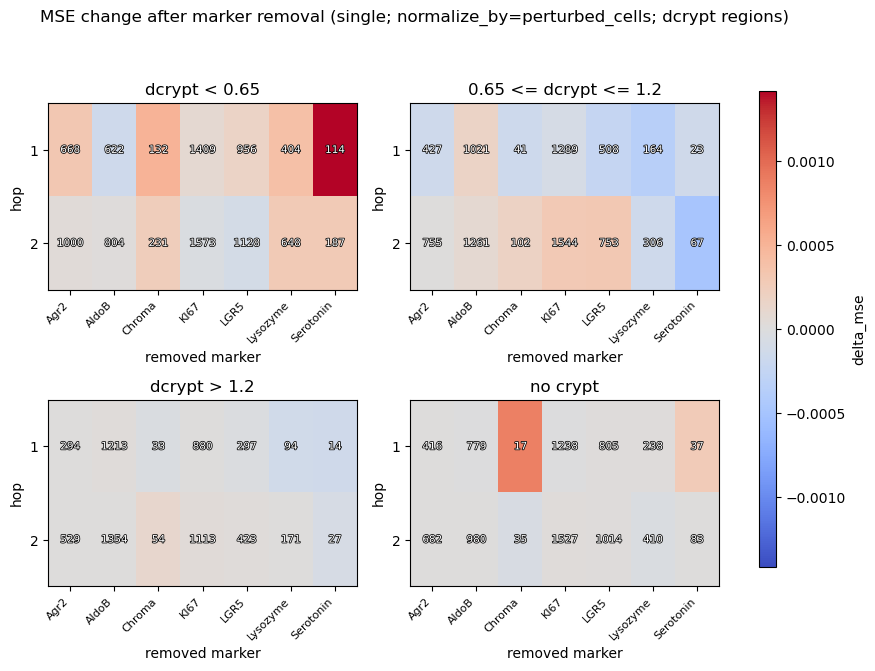

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_dcrypt_regions_marker_summary_single.pdf


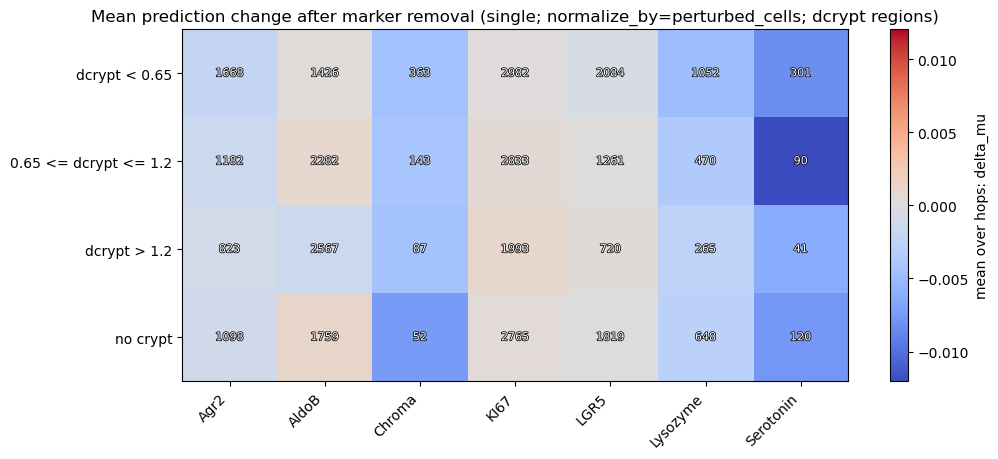

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_dcrypt_regions_marker_summary_single.pdf


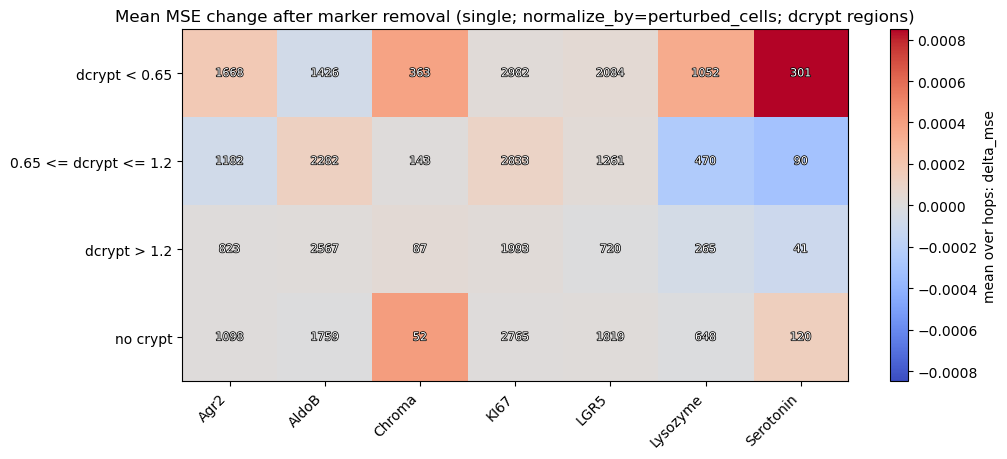

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_by_crypt_lgr5_domains_hop_marker_single.pdf


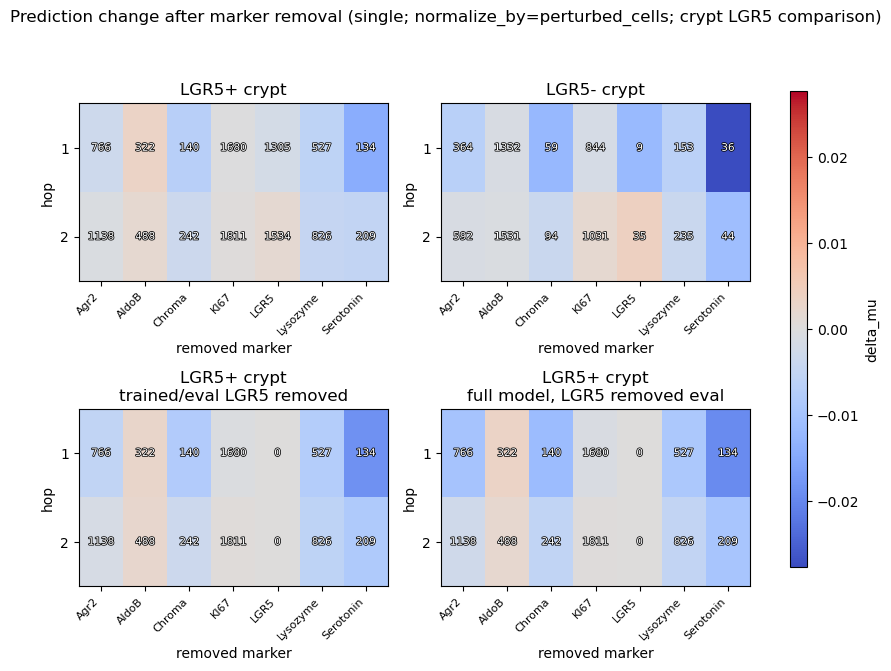

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_by_crypt_lgr5_domains_hop_marker_single.pdf


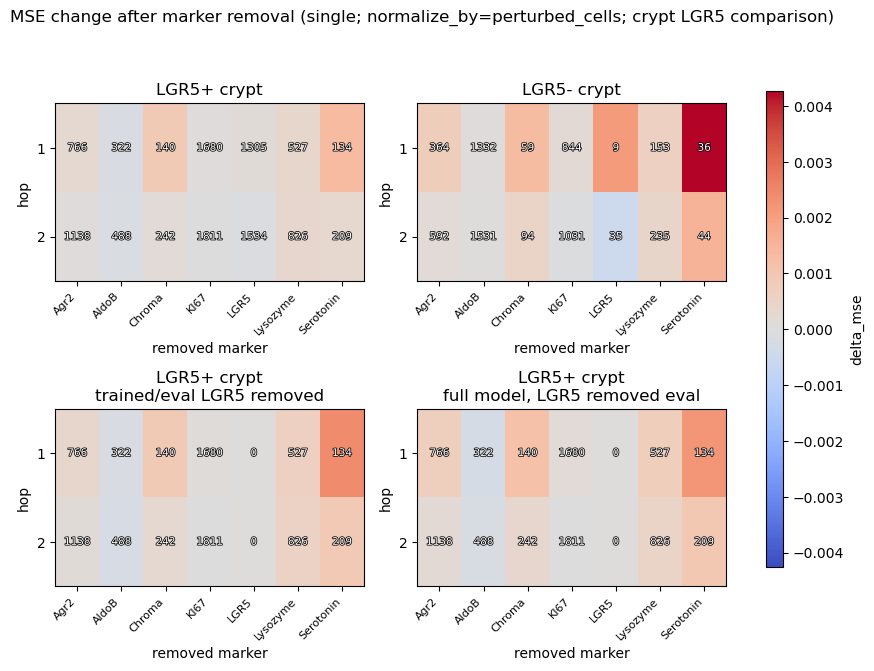

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_crypt_lgr5_domains_marker_summary_single.pdf


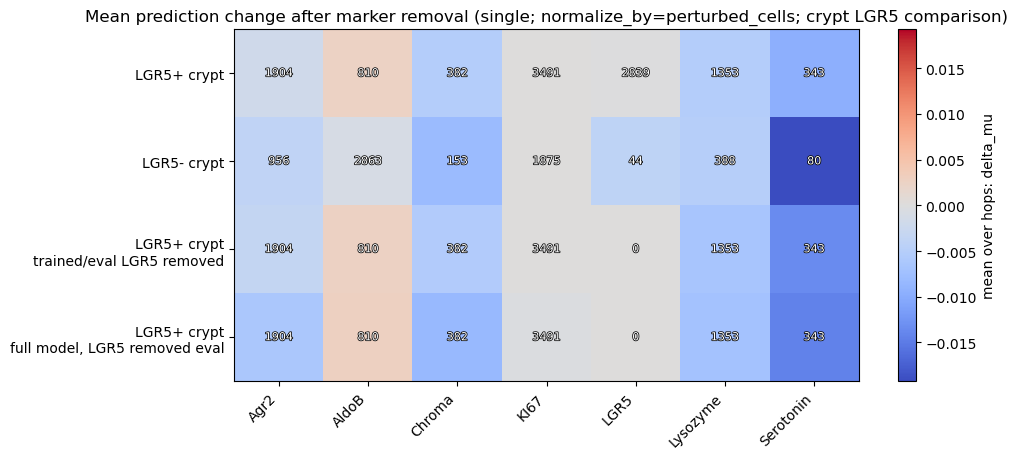

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_crypt_lgr5_domains_marker_summary_single.pdf


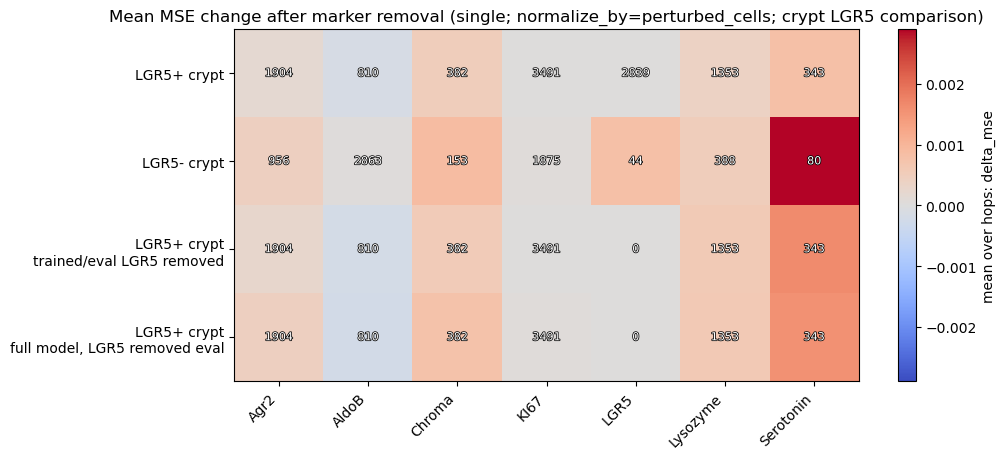

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_by_crypt_marker_removal_hop_marker_single.pdf


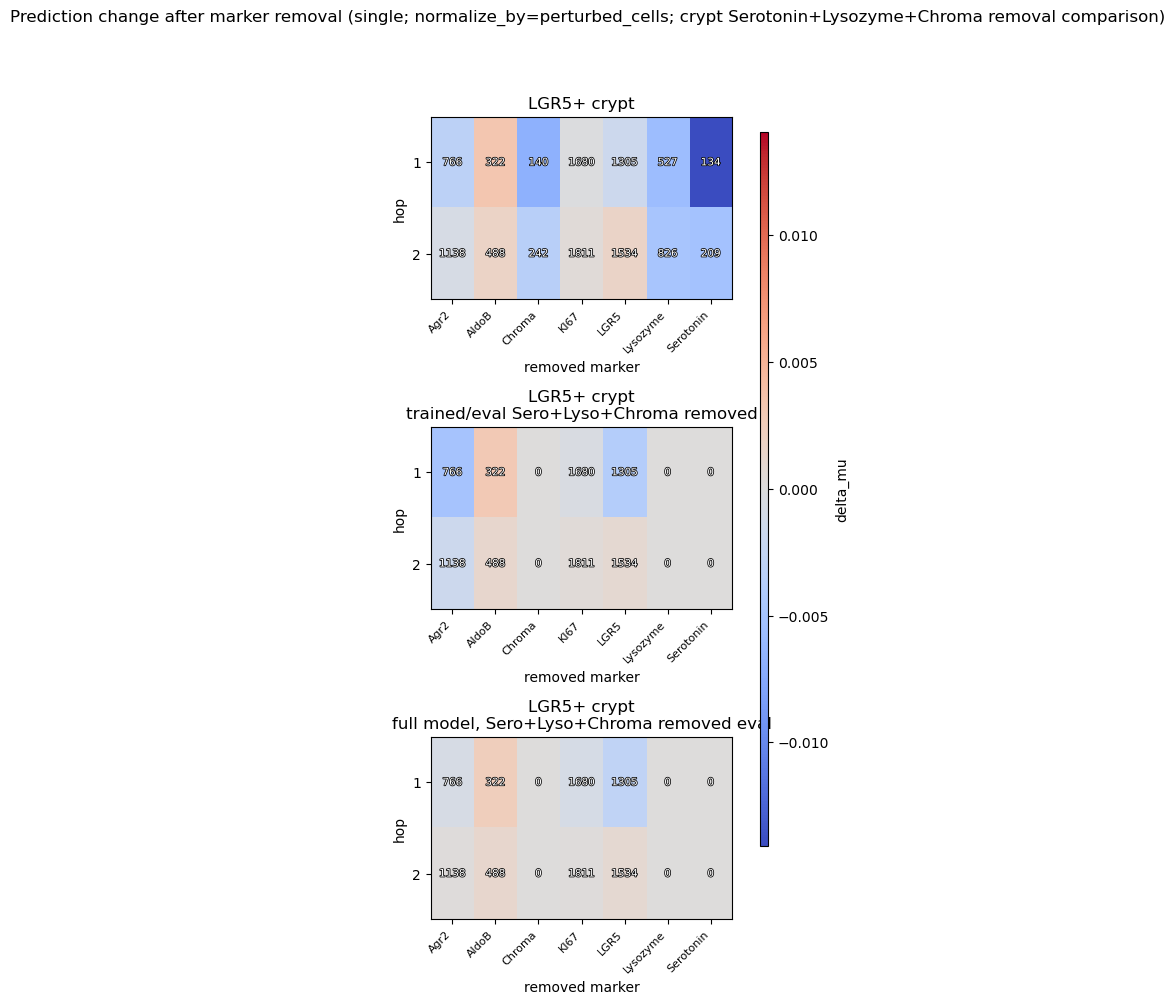

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_by_crypt_marker_removal_hop_marker_single.pdf


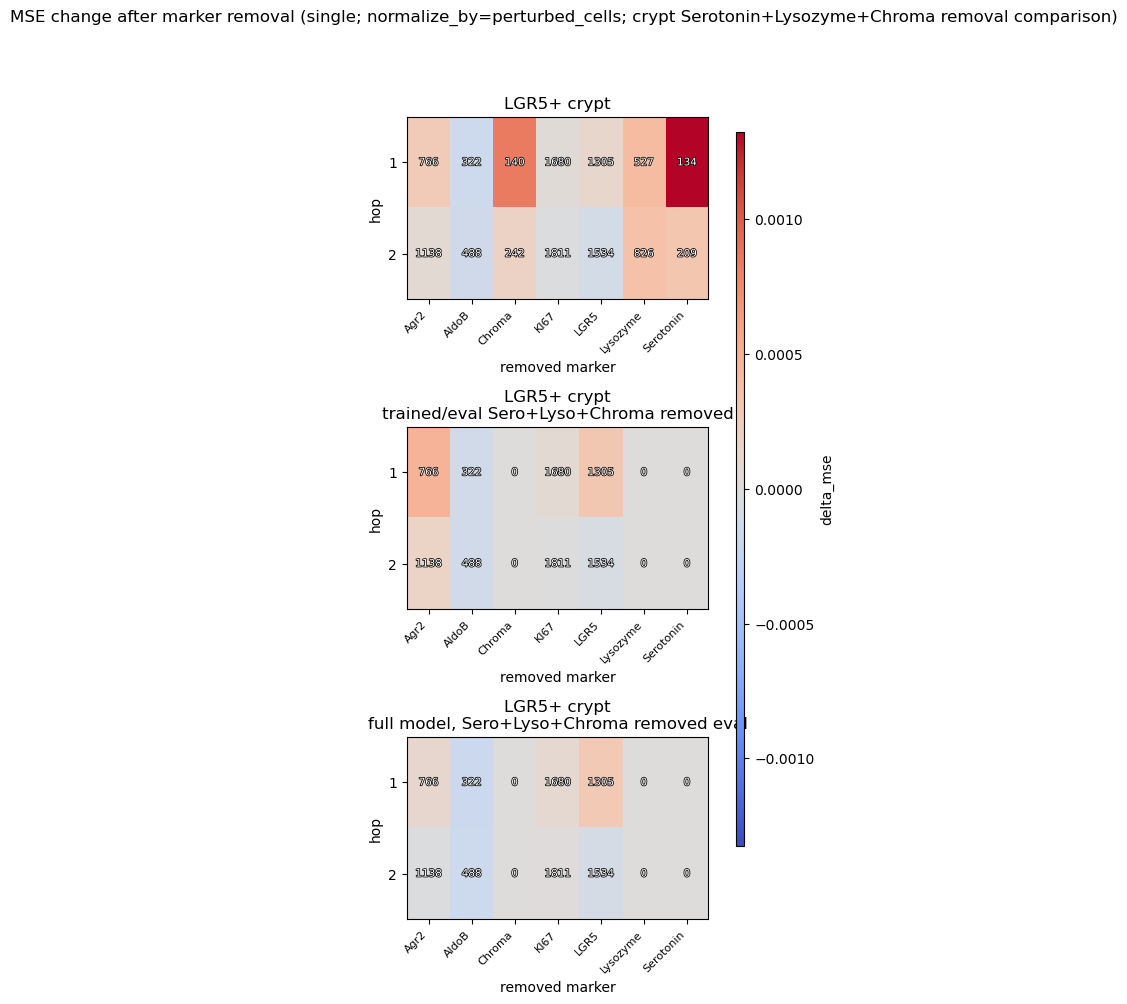

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_crypt_marker_removal_marker_summary_single.pdf


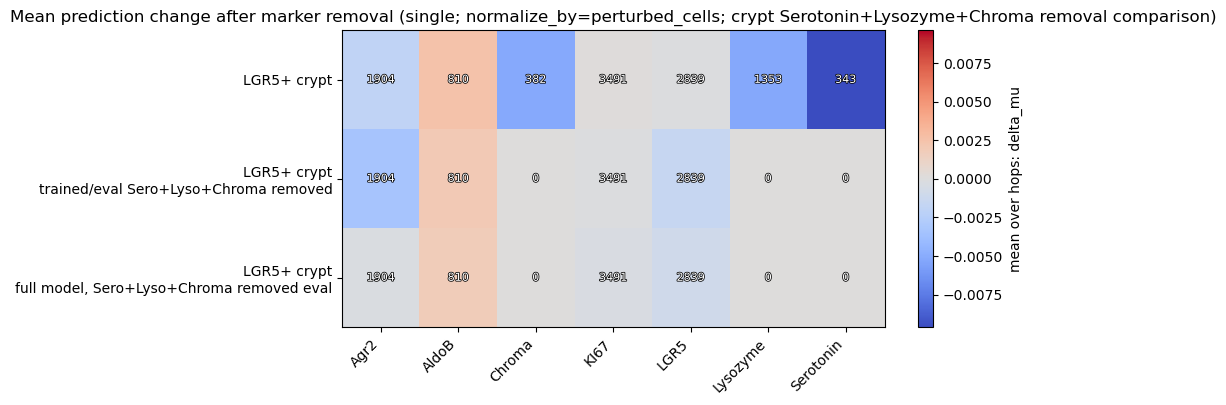

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_crypt_marker_removal_marker_summary_single.pdf


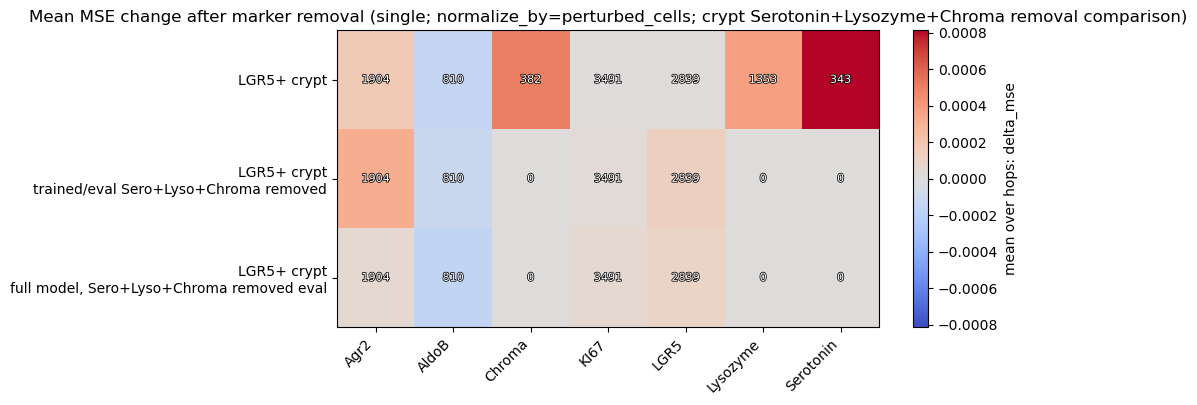

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_by_dcrypt_regions_hop_marker_all.pdf


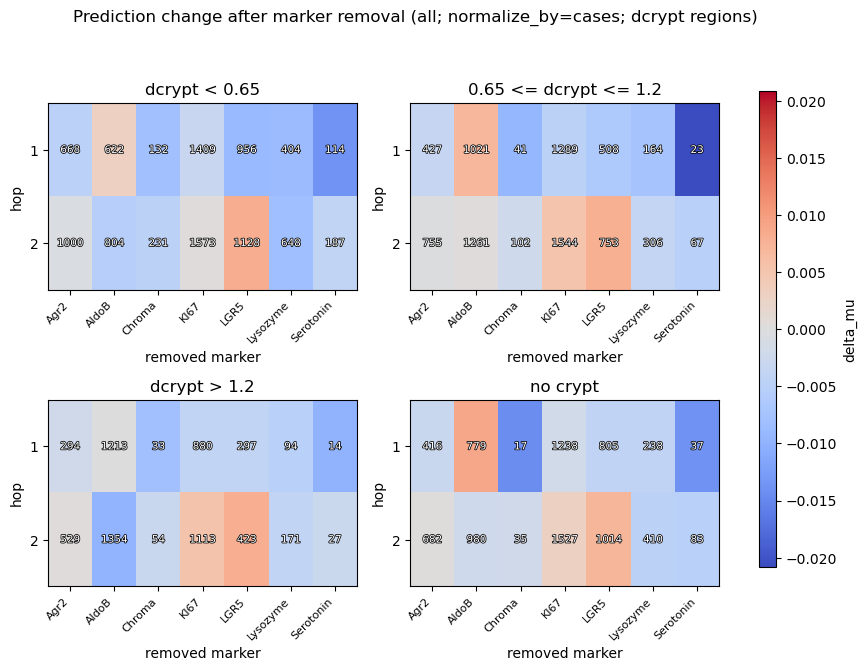

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_by_dcrypt_regions_hop_marker_all.pdf


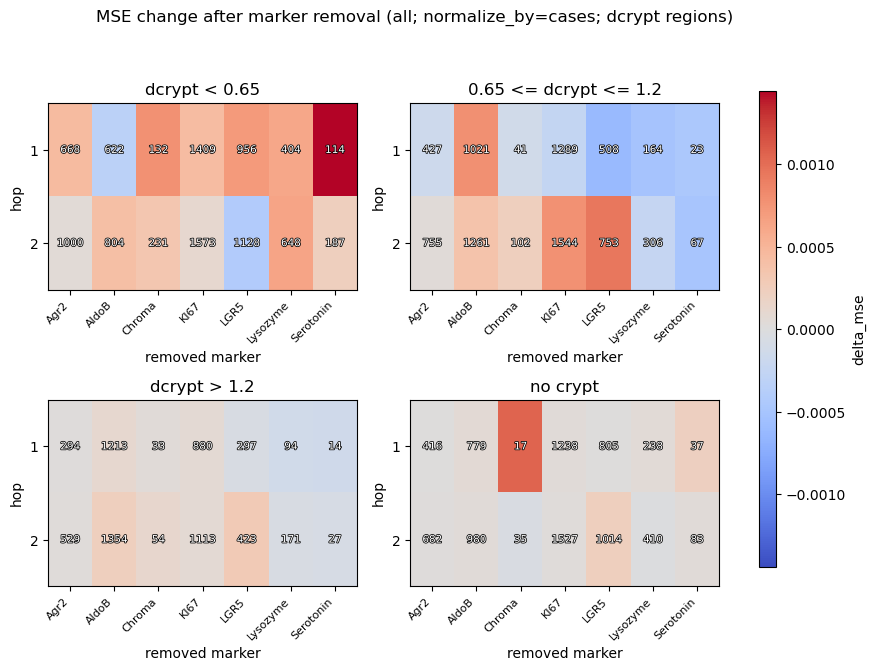

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_dcrypt_regions_marker_summary_all.pdf


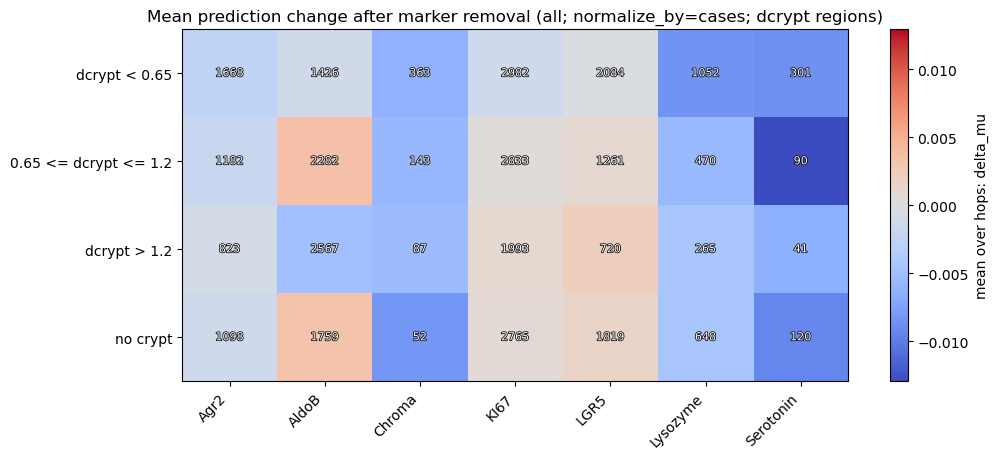

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_dcrypt_regions_marker_summary_all.pdf


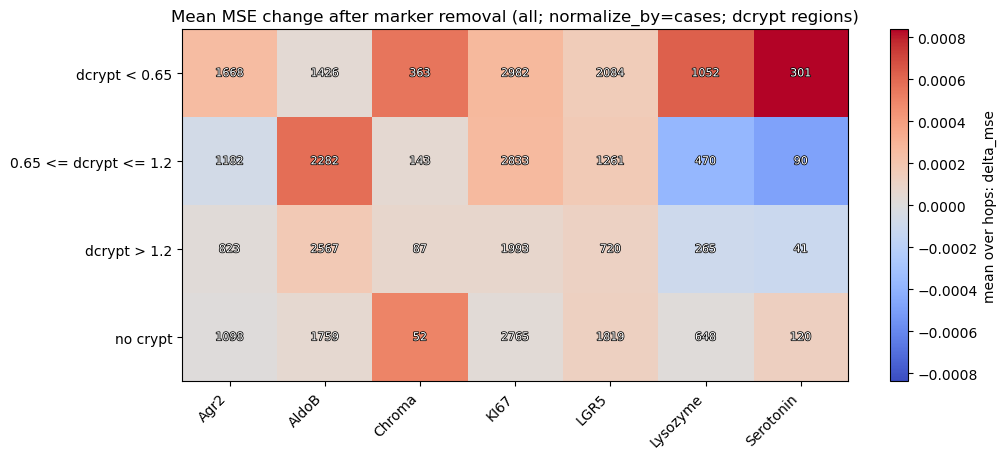

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_by_crypt_lgr5_domains_hop_marker_all.pdf


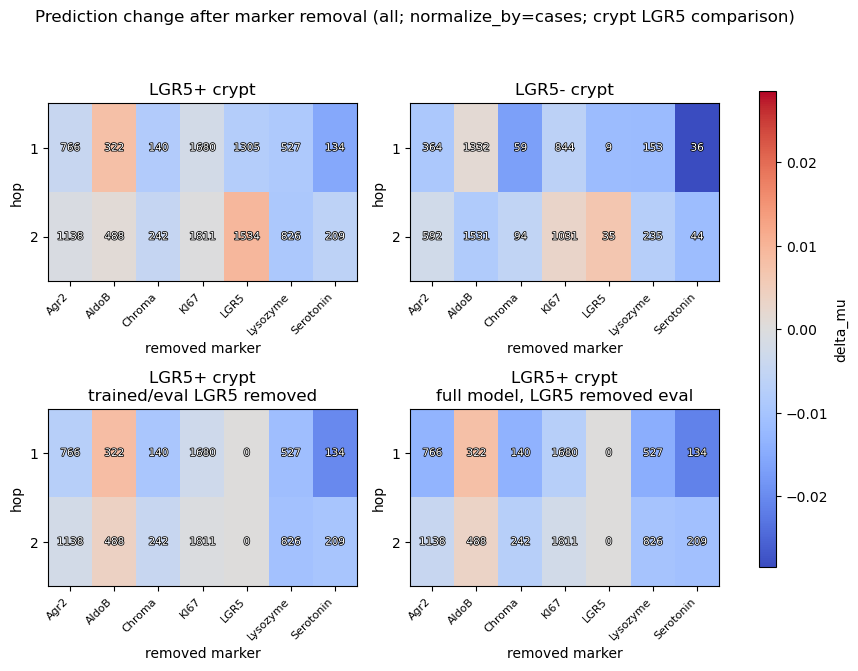

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_by_crypt_lgr5_domains_hop_marker_all.pdf


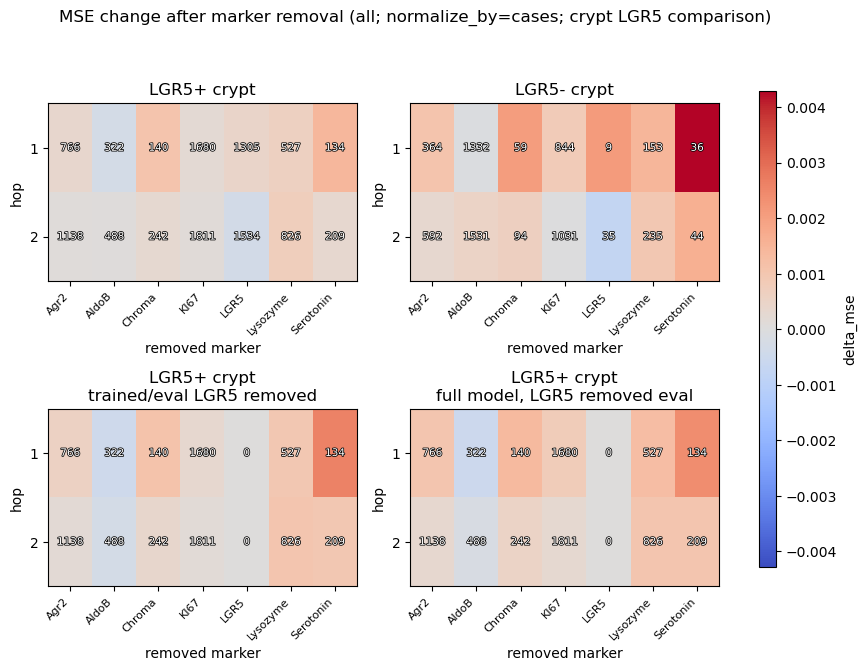

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_crypt_lgr5_domains_marker_summary_all.pdf


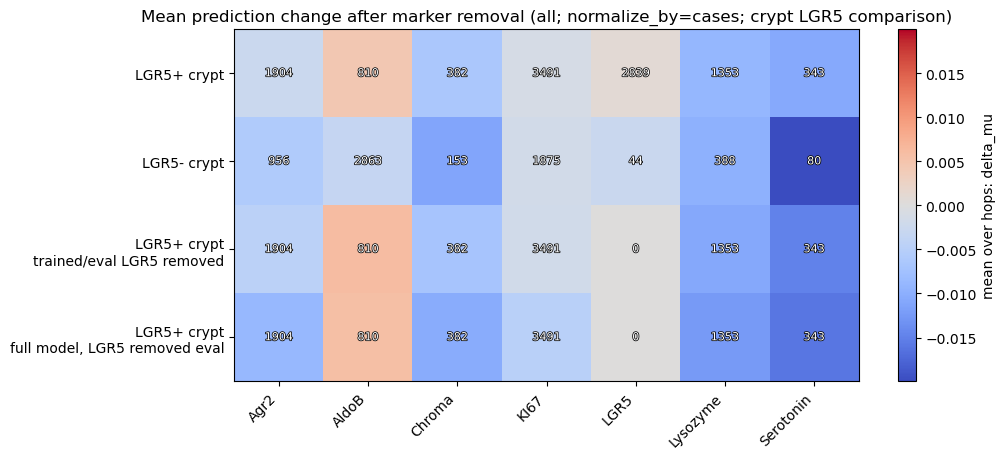

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_crypt_lgr5_domains_marker_summary_all.pdf


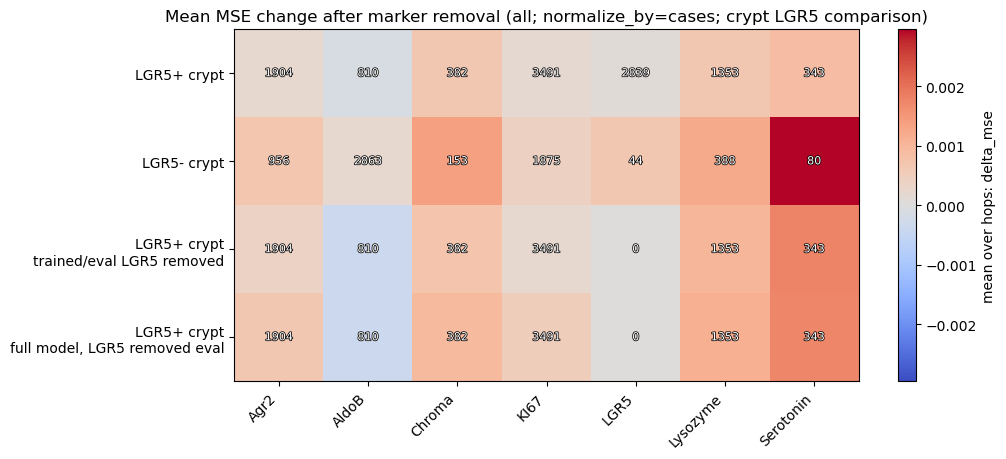

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_by_crypt_marker_removal_hop_marker_all.pdf


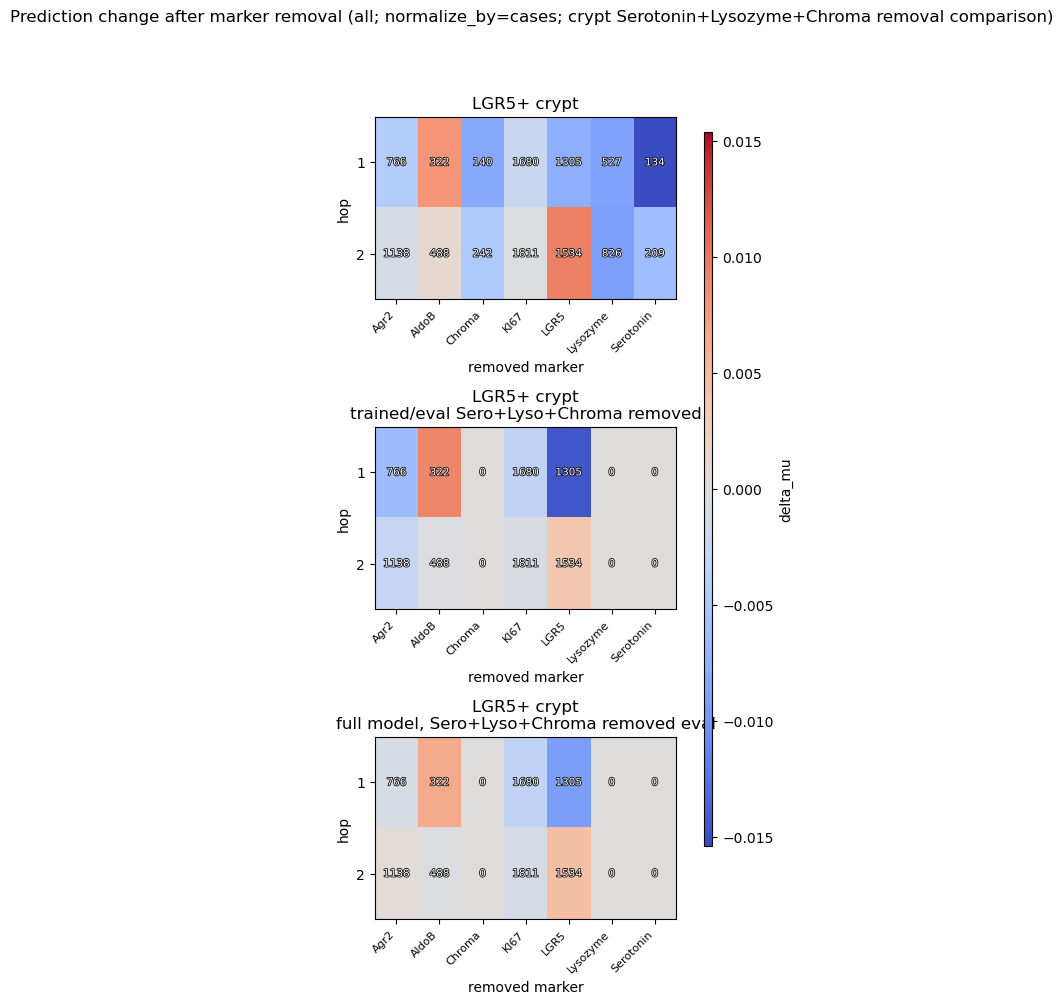

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_by_crypt_marker_removal_hop_marker_all.pdf


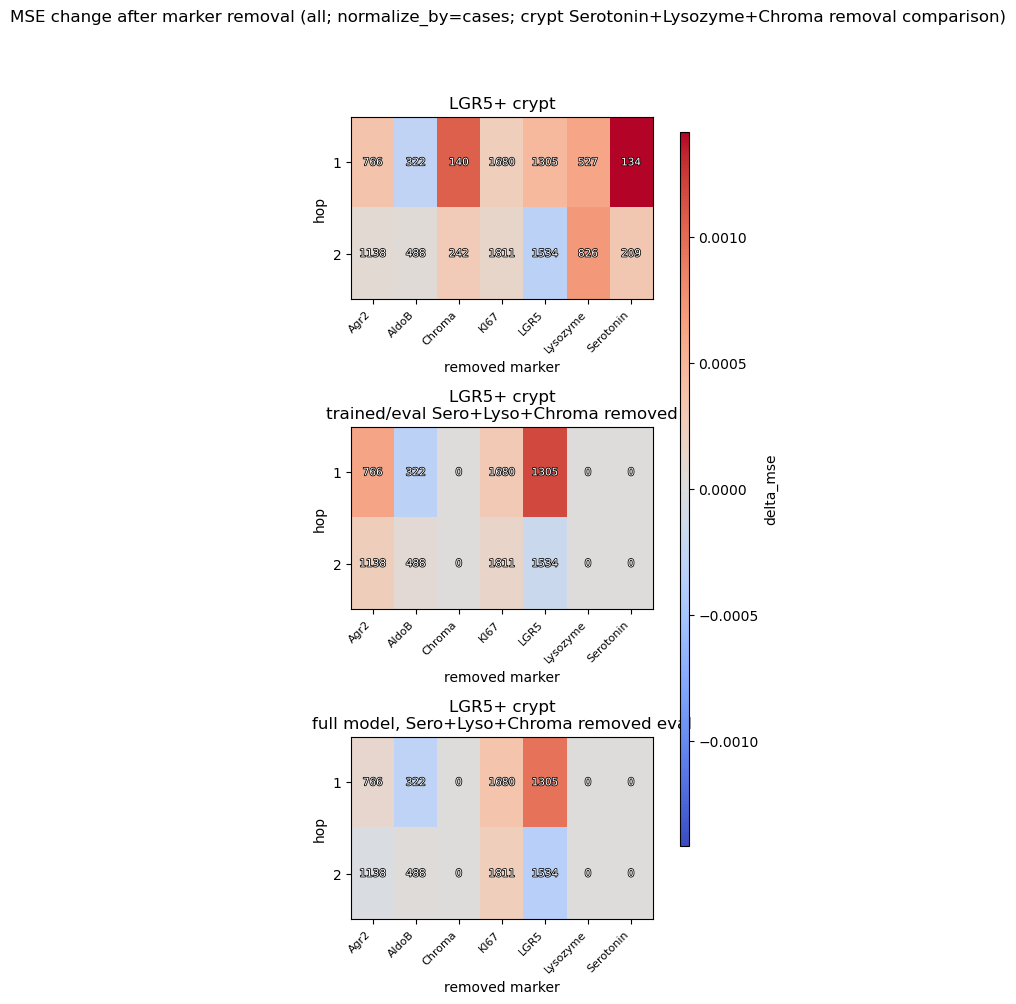

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mu_crypt_marker_removal_marker_summary_all.pdf


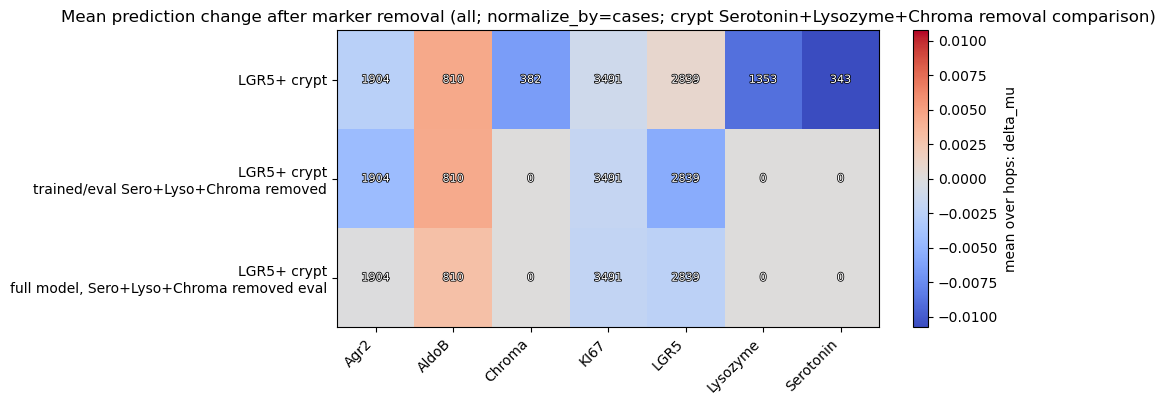

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026/figures/ablation_delta_mse_crypt_marker_removal_marker_summary_all.pdf


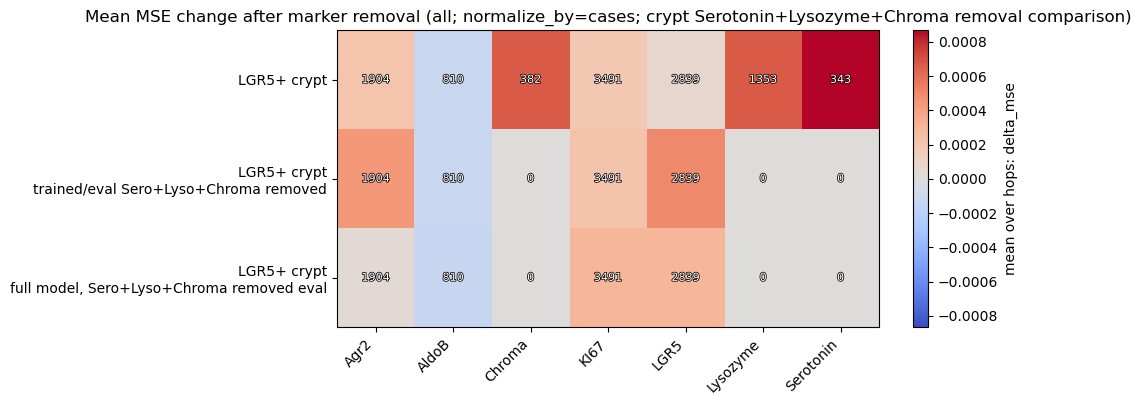

In [89]:
def ablation_annotation_col(mode):
    return "cases" if mode == "all" else "perturbed_cells"


def plot_ablation_hop_marker_panels(
    df,
    value_col,
    mode,
    title,
    filename,
    *,
    group_order,
    n_cols=2,
    cmap="coolwarm",
    center_zero=True,
):
    sub = df[(df["mode"] == mode) & (df["group"].isin(group_order))].copy()
    groups = [g for g in group_order if g in set(sub["group"])]
    n_rows = max(1, int(np.ceil(len(groups) / n_cols)))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows), squeeze=False)
    finite_values = sub[value_col].to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(finite_values)):
        vmax = np.nanmax(np.abs(finite_values))
        vmin = -vmax
    else:
        vmin = vmax = None

    count_col = ablation_annotation_col(mode)
    im = None
    for ax, group in zip(axes.ravel(), groups):
        group_df = sub[sub["group"] == group]
        table = (
            group_df
            .pivot(index="hop", columns="marker", values=value_col)
            .reindex(columns=marker_names)
            .sort_index()
        )
        annotation_table = (
            group_df
            .pivot(index="hop", columns="marker", values=count_col)
            .reindex(index=table.index, columns=table.columns)
        )
        im = ax.imshow(table.to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(DCRYPT_REGION_LABELS[group])
        ax.set_xlabel("removed marker")
        ax.set_ylabel("hop")
        ax.set_xticks(np.arange(len(marker_names)))
        ax.set_xticklabels(marker_names, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(table.index)))
        ax.set_yticklabels(table.index)
        annotate_heatmap_cells(ax, annotation_table, fontsize=7.5)
    for ax in axes.ravel()[len(groups):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.94])
    if im is not None:
        cax = fig.add_axes([0.91, 0.16, 0.02, 0.70])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(value_col)
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


def plot_ablation_region_marker_summary(
    df,
    value_col,
    mode,
    title,
    filename,
    *,
    group_order,
    cmap="coolwarm",
    center_zero=True,
):
    sub = df[(df["mode"] == mode) & (df["group"].isin(group_order))].copy()
    count_col = ablation_annotation_col(mode)
    summary = (
        sub.groupby(["group", "label", "marker"], as_index=False)
        .agg(
            value=(value_col, "mean"),
            annotation_count=(count_col, "sum"),
        )
    )
    table = summary.pivot(index="label", columns="marker", values="value")
    annotation_table = summary.pivot(index="label", columns="marker", values="annotation_count")
    row_labels = [DCRYPT_REGION_LABELS[g] for g in group_order if g in set(sub["group"])]
    table = table.reindex(row_labels)
    table = table.reindex(columns=marker_names)
    annotation_table = annotation_table.reindex(row_labels)
    annotation_table = annotation_table.reindex(columns=marker_names)

    values = table.to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(values)):
        vmax = np.nanmax(np.abs(values))
        vmin = -vmax
    else:
        vmin = vmax = None

    fig, ax = plt.subplots(figsize=(1.05 * len(marker_names) + 3, 0.55 * len(row_labels) + 2.5))
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(marker_names)))
    ax.set_xticklabels(marker_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    annotate_heatmap_cells(ax, annotation_table, fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"mean over hops: {value_col}")
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, ABLATION_NORMALIZE_BY)
    mode_label = f"{mode}; normalize_by={normalize_by}"
    for group_order, suffix, title_prefix, n_cols in [
        (DCRYPT_REGION_ORDER, "dcrypt_regions", "dcrypt regions", 2),
        (CRYPT_COMPARISON_ORDER, "crypt_lgr5_domains", "crypt LGR5 comparison", 2),
        (CRYPT_MARKER_REMOVAL_COMPARISON_ORDER, "crypt_marker_removal", f"crypt {CRYPT_REMOVAL_MARKER_LABEL} removal comparison", 1),
    ]:
        plot_ablation_hop_marker_panels(
            ablation_df,
            "delta_mu",
            mode,
            f"Prediction change after marker removal ({mode_label}; {title_prefix})",
            f"ablation_delta_mu_by_{suffix}_hop_marker_{mode}",
            group_order=group_order,
            n_cols=n_cols,
        )
        plot_ablation_hop_marker_panels(
            ablation_df,
            "delta_mse",
            mode,
            f"MSE change after marker removal ({mode_label}; {title_prefix})",
            f"ablation_delta_mse_by_{suffix}_hop_marker_{mode}",
            group_order=group_order,
            n_cols=n_cols,
        )
        plot_ablation_region_marker_summary(
            ablation_df,
            "delta_mu",
            mode,
            f"Mean prediction change after marker removal ({mode_label}; {title_prefix})",
            f"ablation_delta_mu_{suffix}_marker_summary_{mode}",
            group_order=group_order,
        )
        plot_ablation_region_marker_summary(
            ablation_df,
            "delta_mse",
            mode,
            f"Mean MSE change after marker removal ({mode_label}; {title_prefix})",
            f"ablation_delta_mse_{suffix}_marker_summary_{mode}",
            group_order=group_order,
        )


**Top Marker Tables**

These tables rank markers by their mean ablation effects, averaged over hop distances within each region.

In [90]:
def top_markers_by_group(df, value_col, mode, *, top_n=5, largest=True):
    sub = df[df["mode"] == mode].copy()
    summary = (
        sub.groupby(["group", "label", "marker"], as_index=False)
        .agg(value=(value_col, "mean"), cases=("cases", "sum"), perturbed_cells=("perturbed_cells", "sum"))
    )
    rows = []
    for group in [g for g in ANALYSIS_GROUP_ORDER if g in set(summary["group"])] :
        tmp = summary[summary["group"] == group].sort_values("value", ascending=not largest).head(top_n)
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, ABLATION_NORMALIZE_BY)
    print(f"Top markers by mean delta MSE | mode={mode} | normalize_by={normalize_by}")
    display_table(top_markers_by_group(ablation_df, "delta_mse", mode, top_n=5, largest=True))
    print(f"Most negative prediction changes | mode={mode} | normalize_by={normalize_by}")
    display_table(top_markers_by_group(ablation_df, "delta_mu", mode, top_n=5, largest=False))

Top markers by mean delta MSE | mode=single | normalize_by=perturbed_cells


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.65,Serotonin,0.000849,301,301
1,dcrypt < 0.65,Chroma,0.000379,363,363
2,dcrypt < 0.65,Lysozyme,0.000341,1052,1052
3,dcrypt < 0.65,Agr2,0.000177,1668,1668
4,dcrypt < 0.65,LGR5,0.000040,2084,2084
5,0.65 <= dcrypt <= 1.2,AldoB,0.000126,2282,2282
6,0.65 <= dcrypt <= 1.2,KI67,0.000105,2833,2833
7,0.65 <= dcrypt <= 1.2,LGR5,0.000033,1261,1261
8,0.65 <= dcrypt <= 1.2,Chroma,0.000008,143,143
9,0.65 <= dcrypt <= 1.2,Agr2,-0.000073,1182,1182


Most negative prediction changes | mode=single | normalize_by=perturbed_cells


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.65,Serotonin,-0.008180,301,301
1,dcrypt < 0.65,Lysozyme,-0.004858,1052,1052
2,dcrypt < 0.65,Chroma,-0.004434,363,363
3,dcrypt < 0.65,Agr2,-0.002091,1668,1668
4,dcrypt < 0.65,LGR5,-0.000474,2084,2084
5,0.65 <= dcrypt <= 1.2,Serotonin,-0.012033,90,90
6,0.65 <= dcrypt <= 1.2,Chroma,-0.004059,143,143
7,0.65 <= dcrypt <= 1.2,Lysozyme,-0.003657,470,470
8,0.65 <= dcrypt <= 1.2,Agr2,-0.001501,1182,1182
9,0.65 <= dcrypt <= 1.2,LGR5,0.000050,1261,1261


Top markers by mean delta MSE | mode=all | normalize_by=cases


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.65,Serotonin,0.000838,301,375
1,dcrypt < 0.65,Lysozyme,0.000625,1052,1998
2,dcrypt < 0.65,Chroma,0.000552,363,513
3,dcrypt < 0.65,KI67,0.000275,2982,17003
4,dcrypt < 0.65,Agr2,0.000251,1668,2926
5,0.65 <= dcrypt <= 1.2,AldoB,0.000579,2282,13408
6,0.65 <= dcrypt <= 1.2,KI67,0.000264,2833,13765
7,0.65 <= dcrypt <= 1.2,LGR5,0.000164,1261,5525
8,0.65 <= dcrypt <= 1.2,Chroma,0.000050,143,185
9,0.65 <= dcrypt <= 1.2,Agr2,-0.000061,1182,1932


Most negative prediction changes | mode=all | normalize_by=cases


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.65,Serotonin,-0.008715,301,375
1,dcrypt < 0.65,Lysozyme,-0.008430,1052,1998
2,dcrypt < 0.65,Chroma,-0.006237,363,513
3,dcrypt < 0.65,Agr2,-0.002654,1668,2926
4,dcrypt < 0.65,KI67,-0.001408,2982,17003
5,0.65 <= dcrypt <= 1.2,Serotonin,-0.012937,90,104
6,0.65 <= dcrypt <= 1.2,Chroma,-0.005743,143,185
7,0.65 <= dcrypt <= 1.2,Lysozyme,-0.005562,470,776
8,0.65 <= dcrypt <= 1.2,Agr2,-0.001872,1182,1932
9,0.65 <= dcrypt <= 1.2,KI67,0.000279,2833,13765


**Crypt-Only Tables**

These compact tables repeat the key outputs for the crypt-domain splits, including LGR5-present/absent categories and whole-organoid crypt-marker removal contexts.


In [91]:
# Compact crypt-only comparison tables for the requested LGR5-domain split.
crypt_compare_groups = CRYPT_COMPARISON_ORDER
crypt_baseline_df = baseline_region_df[baseline_region_df["group"].isin(crypt_compare_groups)].copy()
crypt_marker_count_df = marker_count_region_df[marker_count_region_df["group"].isin(crypt_compare_groups)].copy()
crypt_ablation_df = ablation_df[ablation_df["group"].isin(crypt_compare_groups)].copy()

display_table(crypt_baseline_df)
display_table(crypt_marker_count_df, head=16)
display_table(crypt_ablation_df, head=16)
# Compact crypt-only comparison tables for the whole-organoid crypt-marker removal analysis.
crypt_marker_removal_compare_groups = CRYPT_MARKER_REMOVAL_COMPARISON_ORDER
crypt_marker_removal_baseline_df = baseline_region_df[baseline_region_df["group"].isin(crypt_marker_removal_compare_groups)].copy()
crypt_marker_removal_marker_count_df = marker_count_region_df[marker_count_region_df["group"].isin(crypt_marker_removal_compare_groups)].copy()
crypt_marker_removal_ablation_df = ablation_df[ablation_df["group"].isin(crypt_marker_removal_compare_groups)].copy()

display_table(crypt_marker_removal_baseline_df)
display_table(crypt_marker_removal_marker_count_df, head=16)
display_table(crypt_marker_removal_ablation_df, head=16)


,label,model_context,n_nodes,mse,sem_mse,pred_var_mean,sem_pred_var,spearman_pred_var_sqerr
4,LGR5+ crypt,full,16104,0.003982,0.000054,0.002919,0.000022,0.221160
5,LGR5- crypt,full,6378,0.003446,0.000091,0.001586,0.000025,0.358518
6,LGR5+ crypt\ntrained/eval LGR5 removed,lgr5_removed,16104,0.004395,0.000059,0.002847,0.000019,0.229936
7,"LGR5+ crypt\nfull model, LGR5 removed eval",full_eval_lgr5_removed,16104,0.004688,0.000063,0.003007,0.000023,0.229871


,label,model_context,marker,marker_index,n_nodes,n_marker_positive,mean_count_within_rf,fraction_with_marker_visible,spearman_count_true,spearman_count_pred,spearman_count_sqerr,spearman_count_pred_var
28,LGR5+ crypt,full,Agr2,0,16104,1526,1.739878,0.700447,0.179282,0.328223,-0.001449,0.141700
29,LGR5+ crypt,full,AldoB,1,16104,1517,2.158222,0.269001,-0.079947,-0.263387,0.075530,-0.037714
30,LGR5+ crypt,full,Chroma,2,16104,297,0.325633,0.168405,0.119209,0.274881,-0.000831,0.082397
31,LGR5+ crypt,full,KI67,3,16104,9071,10.859538,0.914742,-0.045982,0.080215,-0.103019,-0.111651
32,LGR5+ crypt,full,LGR5,4,16104,7700,8.781297,0.795889,0.221820,0.525767,-0.042423,-0.026244
33,LGR5+ crypt,full,Lysozyme,5,16104,1245,1.348485,0.472429,0.296150,0.545078,0.035933,0.266783
34,LGR5+ crypt,full,Serotonin,6,16104,223,0.236525,0.159650,0.163016,0.339481,0.038639,0.127796
35,LGR5- crypt,full,Agr2,0,6378,297,0.807777,0.339135,0.216410,0.152347,0.213197,0.461322
36,LGR5- crypt,full,AldoB,1,6378,3630,11.271872,0.772186,-0.242830,-0.133447,-0.274165,-0.498418
37,LGR5- crypt,full,Chroma,2,6378,44,0.108498,0.061461,0.187197,0.250811,0.116816,0.306465


,label,mode,normalize_by,model_context,hop,marker,marker_index,delta_mu,abs_delta_mu,delta_mse,abs_delta_mse,cases,perturbed_cells
112,LGR5+ crypt,single,perturbed_cells,full,1,Agr2,0,-0.003118,0.006036,0.000256,0.000664,766,766
113,LGR5+ crypt,single,perturbed_cells,full,1,AldoB,1,0.003240,0.006849,-0.000151,0.000697,322,322
114,LGR5+ crypt,single,perturbed_cells,full,1,Chroma,2,-0.006857,0.009097,0.000840,0.001239,140,140
115,LGR5+ crypt,single,perturbed_cells,full,1,KI67,3,-0.000112,0.003692,0.000035,0.000351,1680,1680
116,LGR5+ crypt,single,perturbed_cells,full,1,LGR5,4,-0.001761,0.003915,0.000118,0.000412,1305,1305
117,LGR5+ crypt,single,perturbed_cells,full,1,Lysozyme,5,-0.005715,0.007189,0.000395,0.000778,527,527
118,LGR5+ crypt,single,perturbed_cells,full,1,Serotonin,6,-0.014086,0.015612,0.001325,0.002302,134,134
119,LGR5+ crypt,single,perturbed_cells,full,2,Agr2,0,-0.000687,0.002546,0.000064,0.000254,1138,1138
120,LGR5+ crypt,single,perturbed_cells,full,2,AldoB,1,0.001738,0.004099,-0.000129,0.000462,488,488
121,LGR5+ crypt,single,perturbed_cells,full,2,Chroma,2,-0.003422,0.004323,0.000166,0.000399,242,242


,label,model_context,n_nodes,mse,sem_mse,pred_var_mean,sem_pred_var,spearman_pred_var_sqerr
4,LGR5+ crypt,full,16104,0.003982,0.000054,0.002919,0.000022,0.221160
8,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,crypt_markers_removed,16104,0.004285,0.000059,0.003005,0.000022,0.217609
9,"LGR5+ crypt\nfull model, Sero+Lyso+Chroma remo...",full_eval_crypt_markers_removed,16104,0.005201,0.000067,0.002401,0.000016,0.249925


,label,model_context,marker,marker_index,n_nodes,n_marker_positive,mean_count_within_rf,fraction_with_marker_visible,spearman_count_true,spearman_count_pred,spearman_count_sqerr,spearman_count_pred_var
28,LGR5+ crypt,full,Agr2,0,16104,1526,1.739878,0.700447,0.179282,0.328223,-0.001449,0.141700
29,LGR5+ crypt,full,AldoB,1,16104,1517,2.158222,0.269001,-0.079947,-0.263387,0.075530,-0.037714
30,LGR5+ crypt,full,Chroma,2,16104,297,0.325633,0.168405,0.119209,0.274881,-0.000831,0.082397
31,LGR5+ crypt,full,KI67,3,16104,9071,10.859538,0.914742,-0.045982,0.080215,-0.103019,-0.111651
32,LGR5+ crypt,full,LGR5,4,16104,7700,8.781297,0.795889,0.221820,0.525767,-0.042423,-0.026244
33,LGR5+ crypt,full,Lysozyme,5,16104,1245,1.348485,0.472429,0.296150,0.545078,0.035933,0.266783
34,LGR5+ crypt,full,Serotonin,6,16104,223,0.236525,0.159650,0.163016,0.339481,0.038639,0.127796
56,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,crypt_markers_removed,Agr2,0,16104,1526,1.739878,0.700447,0.179282,0.367458,0.009191,0.194911
57,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,crypt_markers_removed,AldoB,1,16104,1517,2.158222,0.269001,-0.079947,-0.266046,0.067880,-0.086971
58,LGR5+ crypt\ntrained/eval Sero+Lyso+Chroma rem...,crypt_markers_removed,Chroma,2,16104,0,0.000000,0.000000,NaN,NaN,NaN,NaN


,label,mode,normalize_by,model_context,hop,marker,marker_index,delta_mu,abs_delta_mu,delta_mse,abs_delta_mse,cases,perturbed_cells
112,LGR5+ crypt,single,perturbed_cells,full,1,Agr2,0,-0.003118,0.006036,0.000256,0.000664,766,766
113,LGR5+ crypt,single,perturbed_cells,full,1,AldoB,1,0.003240,0.006849,-0.000151,0.000697,322,322
114,LGR5+ crypt,single,perturbed_cells,full,1,Chroma,2,-0.006857,0.009097,0.000840,0.001239,140,140
115,LGR5+ crypt,single,perturbed_cells,full,1,KI67,3,-0.000112,0.003692,0.000035,0.000351,1680,1680
116,LGR5+ crypt,single,perturbed_cells,full,1,LGR5,4,-0.001761,0.003915,0.000118,0.000412,1305,1305
117,LGR5+ crypt,single,perturbed_cells,full,1,Lysozyme,5,-0.005715,0.007189,0.000395,0.000778,527,527
118,LGR5+ crypt,single,perturbed_cells,full,1,Serotonin,6,-0.014086,0.015612,0.001325,0.002302,134,134
119,LGR5+ crypt,single,perturbed_cells,full,2,Agr2,0,-0.000687,0.002546,0.000064,0.000254,1138,1138
120,LGR5+ crypt,single,perturbed_cells,full,2,AldoB,1,0.001738,0.004099,-0.000129,0.000462,488,488
121,LGR5+ crypt,single,perturbed_cells,full,2,Chroma,2,-0.003422,0.004323,0.000166,0.000399,242,242


**Save Results**

Save the configuration, result tables, figures, and training metadata for the experiment run.

In [92]:
def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_experiment(save_dir, config, results, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    dcrypt_region_count_df.to_csv(save_dir / "dcrypt_region_node_counts.csv", index=False)
    analysis_group_count_df.to_csv(save_dir / "analysis_group_node_counts.csv", index=False)
    baseline_region_df.to_csv(save_dir / "baseline_region_metrics.csv", index=False)
    marker_count_region_df.to_csv(save_dir / "local_marker_count_region_metrics.csv", index=False)
    ablation_df.to_csv(save_dir / "region_marker_ablation_metrics.csv", index=False)
    group_subgraph_info.to_csv(save_dir / "group_subgraph_counts.csv", index=False)
    crypt_marker_removal_baseline_df.to_csv(save_dir / "crypt_marker_removal_baseline_metrics.csv", index=False)
    crypt_marker_removal_marker_count_df.to_csv(save_dir / "crypt_marker_removal_marker_count_metrics.csv", index=False)
    crypt_marker_removal_ablation_df.to_csv(save_dir / "crypt_marker_removal_ablation_metrics.csv", index=False)
    print(f"Saved experiment -> {save_dir}")


experiment_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_plots": TARGET_INDEX_FOR_PLOTS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    "target_transform": target_transform.name,
    "dcrypt_field": DCRYPT_FIELD,
    "dcrypt_region_order": DCRYPT_REGION_ORDER,
    "crypt_comparison_order": CRYPT_COMPARISON_ORDER,
    "crypt_marker_removal_comparison_order": CRYPT_MARKER_REMOVAL_COMPARISON_ORDER,
    "lgr5_marker_name": LGR5_MARKER_NAME,
    "crypt_removal_marker_names": list(CRYPT_REMOVAL_MARKER_NAMES),
    "crypt_removal_marker_label": CRYPT_REMOVAL_MARKER_LABEL,
    "model_context_by_group": MODEL_CONTEXT_BY_GROUP,
    "model": {
        "class": MODEL_CLASS,
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "ablation": {
        "modes": ABLATION_MODES,
        "normalize_by": ABLATION_NORMALIZE_BY,
        "normalize_by_by_mode": ABLATION_NORMALIZE_BY_BY_MODE,
        "max_subgraphs_per_group": MAX_SUBGRAPHS_PER_GROUP,
        "min_group_nodes": MIN_GROUP_NODES,
        "batch_size": PERTURBATION_BATCH_SIZE,
    },
    "local_count_hops": LOCAL_COUNT_HOPS,
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
    },
    "filters": {
        "blacklist_n_keys": len(blacklist),
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "marker_names": list(marker_names),
    "field_specs": field_specs,
    "figures_dir": str(FIGURES_DIR),
}

experiment_results = {
    "dcrypt_region_count_df": dcrypt_region_count_df,
    "analysis_group_count_df": analysis_group_count_df,
    "baseline_region_df": baseline_region_df,
    "marker_count_region_df": marker_count_region_df,
    "ablation_df": ablation_df,
    "group_subgraph_info": group_subgraph_info,
    "crypt_baseline_df": crypt_baseline_df,
    "crypt_marker_count_df": crypt_marker_count_df,
    "crypt_ablation_df": crypt_ablation_df,
    "crypt_marker_removal_baseline_df": crypt_marker_removal_baseline_df,
    "crypt_marker_removal_marker_count_df": crypt_marker_removal_marker_count_df,
    "crypt_marker_removal_ablation_df": crypt_marker_removal_ablation_df,
    "training_log": training_log,
    "lgr5_removed_training_log": lgr5_removed_training_log,
    "crypt_markers_removed_training_log": crypt_markers_removed_training_log,
    "full_eval_lgr5_removed_metrics": {
        "mse": float(np.mean(sqerr_full_eval_lgr5_removed)),
        "mean_pred_var": float(np.mean(pred_var_full_eval_lgr5_removed)),
        "spearman_pred_var_sqerr": spearman_corr(pred_var_full_eval_lgr5_removed, sqerr_full_eval_lgr5_removed),
    },
    "full_eval_crypt_markers_removed_metrics": {
        "mse": float(np.mean(sqerr_full_eval_crypt_markers_removed)),
        "mean_pred_var": float(np.mean(pred_var_full_eval_crypt_markers_removed)),
        "spearman_pred_var_sqerr": spearman_corr(pred_var_full_eval_crypt_markers_removed, sqerr_full_eval_crypt_markers_removed),
    },
    "split_info": split_info,
    "outlier_info": outlier_info,
}

save_experiment(
    SAVE_DIR,
    experiment_config,
    experiment_results,
    notes="dcrypt-region marker informativeness analysis with baseline metrics, ablation, local RF marker counts, LGR5 crypt-domain comparison, and whole-organoid crypt-marker removal contexts.",
)

Saved experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260520_101026
